In [1]:
import os
import numpy as np
import pandas as pd
import traceback
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.signal import periodogram
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.tsa.seasonal import STL

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

from threadpoolctl import threadpool_limits

# Extracción de características estructurales en series de tiempo

En esta etapa, cada serie de tiempo es transformada en un conjunto de variables que describen su comportamiento global. Este proceso no tiene como objetivo predecir directamente, sino **representar la estructura interna de la serie** de forma cuantificable.

Sea una serie de tiempo univariada:

$$
Y = \{y_1, y_2, \dots, y_T\}
$$

Se construye una función de transformación:

$$
\phi(Y) = \mathbf{x} \in \mathbb{R}^p
$$

donde cada componente de $\mathbf{x}$ corresponde a una característica estructural.

---

## 1. Normalización de la serie

Para evitar que la escala domine el análisis, se utilizan dos transformaciones:

### Z-score

$$
z_t = \frac{y_t - \bar{y}}{s_y}
$$

donde:
- $\bar{y}$ es la media
- $s_y$ es la desviación estándar

### Escalamiento robusto

$$
r_t = \frac{y_t - \text{Med}(Y)}{\text{IQR}(Y)}
$$

donde:
- $\text{Med}(Y)$ es la mediana
- $\text{IQR}(Y) = Q_{0.75} - Q_{0.25}$

---

## 2. Medidas de complejidad e incertidumbre

### Entropía de Shannon

$$
H(Y) = -\sum_{i=1}^{B} p_i \log p_i
$$

donde $p_i$ es la probabilidad empírica en el bin $i$.

### Entropía espectral

$$
H_s(Y) = -\sum_{j} q_j \log q_j
$$

donde $q_j$ es la energía relativa en la frecuencia $j$.

👉 Interpretación:
- valores altos → mayor desorden
- valores bajos → mayor regularidad

---

## 3. Dependencia temporal

### Autocorrelación

$$
\rho_k = 
\frac{\sum_{t=k+1}^{T} (y_t - \bar{y})(y_{t-k} - \bar{y})}
{\sum_{t=1}^{T} (y_t - \bar{y})^2}
$$

### Decaimiento de autocorrelación

Se define como el primer lag donde:

$$
|\rho_k| < 0.2
$$

👉 Interpretación:
- valores altos → memoria larga
- valores bajos → comportamiento más aleatorio

---

## 4. Irregularidad local

### Proporción de puntos de giro

$$
TPR = \frac{1}{T-2} \sum_{t=2}^{T-1}
\mathbb{I}\left$$
(y_t > y_{t-1} \land y_t > y_{t+1}) \lor 
(y_t < y_{t-1} \land y_t < y_{t+1})
\right$$
$$

### Proporción de outliers (robusto)

$$
z_t^* = 0.6745 \frac{y_t - \text{Med}(Y)}{\text{MAD}(Y)}
$$

$$
\text{OutlierRatio} = \frac{1}{T} \sum \mathbb{I}(|z_t^*| > \tau)
$$

👉 Captura ruido, saltos y comportamiento errático.

---

## 5. Tendencia y estructura determinística

### Modelo lineal

$$
y_t = \beta_0 + \beta_1 t + \varepsilon_t
$$

Se utiliza:
- pendiente $\beta_1$
- coeficiente de determinación $R^2$

### No linealidad

$$
\Delta R^2 = R^2_{\text{cuad}} - R^2_{\text{lin}}
$$

---

## 6. Estacionalidad (STL)

Descomposición:

$$
Y_t = T_t + S_t + R_t
$$

### Fuerza de tendencia

$$
F_T = 1 - \frac{\text{Var}(R_t)}{\text{Var}(T_t + R_t)}
$$

### Fuerza de estacionalidad

$$
F_S = 1 - \frac{\text{Var}(R_t)}{\text{Var}(S_t + R_t)}
$$

---

## 7. Frecuencia dominante

A partir del periodograma:

$$
f^* = \arg\max I(f)
$$

$$
\eta = \frac{I(f^*)}{\sum I(f)}
$$

👉 Indica periodicidad dominante.

---

## 8. Estacionariedad

Se aplican dos pruebas:

### ADF
$$
H_0: \text{raíz unitaria}
$$

### KPSS
$$
H_0: \text{estacionaria}
$$

Se define conflicto:

$$
\text{Conflict} = 
\mathbb{I}(\text{ADF} \neq \text{KPSS})
$$

---

## 9. Exponente de Hurst

Mide memoria de largo plazo:

$$
H \approx 2 \cdot \text{slope}(\log(\tau) \text{ vs } \log(lag))
$$

- $H > 0.5$: persistencia
- $H < 0.5$: anti-persistencia
- $H \approx 0.5$: ruido blanco

---

## 10. Puntos de cambio

Se detectan rupturas estructurales:

$$
CPR = \frac{N_{cp}}{T}
$$

donde $N_{cp}$ es el número de cambios detectados.

---

## Interpretación global

Estas características no describen valores puntuales, sino:

- **regularidad vs ruido**
- **estructura vs aleatoriedad**
- **memoria temporal**
- **complejidad dinámica**

En conjunto, permiten representar cada serie como un vector:

$$
\mathbf{x}_i = \phi(Y_i)
$$

y analizar el sistema completo en un espacio estructural de baja dimensión.

In [2]:
# =========================================================
# INTENTO DE IMPORTAR "ruptures"
# =========================================================
try:
    # Intentamos importar la librería ruptures,
    # que sirve para detectar puntos de cambio estructural en series de tiempo.
    import ruptures as rpt

    # Si la importación funciona, dejamos una bandera en True.
    RUPTURES_OK = True

except Exception:
    # Si falla la importación, dejamos la bandera en False
    # para que el resto del código no se rompa.
    RUPTURES_OK = False


# =========================================================
# FUNCIÓN: safe_float
# =========================================================
def safe_float(x):
    # Esta función intenta convertir cualquier valor x a float.
    # Si no se puede, devuelve np.nan.
    try:
        # Convertimos x a float.
        x = float(x)

        # Si x es finito (no inf, no -inf, no nan), lo devolvemos.
        # Si no es finito, devolvemos np.nan.
        return x if np.isfinite(x) else np.nan

    except Exception:
        # Si cualquier cosa falla, devolvemos np.nan.
        return np.nan


# =========================================================
# FUNCIÓN: zscore_series
# =========================================================
def zscore_series(x):
    # Convertimos x a numpy array de tipo float.
    x = np.asarray(x, dtype=float)

    # Nos quedamos solo con valores finitos.
    x = x[np.isfinite(x)]

    # Si la serie queda vacía, devolvemos la serie vacía.
    if len(x) == 0:
        return x

    # Calculamos la media de la serie.
    mu = np.mean(x)

    # Calculamos la desviación estándar.
    sd = np.std(x)

    # Si la desviación estándar es cero,
    # significa que todos los valores son iguales.
    if sd == 0:
        # En ese caso devolvemos un vector de ceros del mismo tamaño.
        return np.zeros_like(x)

    # Si sd > 0, devolvemos la serie estandarizada:
    # (x - media) / desviación estándar
    return (x - mu) / sd


# =========================================================
# FUNCIÓN: robust_scale_series
# =========================================================
def robust_scale_series(x):
    # Convertimos a array float.
    x = np.asarray(x, dtype=float)

    # Filtramos valores finitos.
    x = x[np.isfinite(x)]

    # Si no hay datos, devolvemos el array vacío.
    if len(x) == 0:
        return x

    # Calculamos la mediana.
    med = np.median(x)

    # Calculamos percentiles 25 y 75.
    q1, q3 = np.percentile(x, [25, 75])

    # Calculamos el rango intercuartílico.
    iqr = q3 - q1

    # Si el IQR es cero, no podemos dividir.
    if iqr == 0:
        # Entonces centramos respecto a la mediana.
        return x - med

    # Si IQR > 0, escalamos de manera robusta:
    # (x - mediana) / IQR
    return (x - med) / iqr


# =========================================================
# FUNCIÓN: shannon_entropy
# =========================================================
def shannon_entropy(x, bins=20):
    # Convertimos a array float.
    x = np.asarray(x, dtype=float)

    # Nos quedamos con valores finitos.
    x = x[np.isfinite(x)]

    # Si hay muy pocos datos, no calculamos entropía.
    if len(x) < 5:
        return np.nan

    # Construimos un histograma con "bins" cajas.
    # density=True hace que se calcule una densidad.
    hist, _ = np.histogram(x, bins=bins, density=True)

    # Nos quedamos solo con valores positivos del histograma.
    hist = hist[hist > 0]

    # Si no hay bins positivos, devolvemos nan.
    if len(hist) == 0:
        return np.nan

    # Normalizamos para que sumen 1 y puedan interpretarse como probabilidades.
    p = hist / hist.sum()

    # Calculamos entropía de Shannon: -sum(p log p)
    return safe_float(-np.sum(p * np.log(p)))


# =========================================================
# FUNCIÓN: spectral_entropy
# =========================================================
def spectral_entropy(x):
    try:
        # Convertimos a array float.
        x = np.asarray(x, dtype=float)

        # Filtramos finitos.
        x = x[np.isfinite(x)]

        # Si la serie es demasiado corta, devolvemos nan.
        if len(x) < 8:
            return np.nan

        # Calculamos el periodograma:
        # f = frecuencias
        # pxx = potencia espectral
        f, pxx = periodogram(x)

        # Filtramos potencias finitas.
        pxx = pxx[np.isfinite(pxx)]

        # Filtramos potencias positivas.
        pxx = pxx[pxx > 0]

        # Si no queda nada, devolvemos nan.
        if len(pxx) == 0:
            return np.nan

        # Normalizamos la energía total para obtener "probabilidades espectrales".
        p = pxx / pxx.sum()

        # Calculamos entropía espectral.
        return safe_float(-np.sum(p * np.log(p)))

    except Exception:
        # Si algo falla, devolvemos nan.
        return np.nan


# =========================================================
# FUNCIÓN: dominant_frequency_features
# =========================================================
def dominant_frequency_features(x):
    try:
        # Convertimos a array float.
        x = np.asarray(x, dtype=float)

        # Filtramos finitos.
        x = x[np.isfinite(x)]

        # Si hay pocos datos, no calculamos nada.
        if len(x) < 8:
            return np.nan, np.nan

        # Calculamos periodograma.
        f, pxx = periodogram(x)

        # Si solo hay frecuencia cero o no hay suficientes puntos, devolvemos nan.
        if len(f) <= 1:
            return np.nan, np.nan

        # Quitamos la frecuencia cero, porque no nos interesa como frecuencia dominante.
        f = f[1:]
        pxx = pxx[1:]

        # Si no hay energía o la energía total es cero, devolvemos nan.
        if len(pxx) == 0 or np.sum(pxx) == 0:
            return np.nan, np.nan

        # Buscamos el índice de la mayor potencia espectral.
        idx = np.argmax(pxx)

        # Devolvemos:
        # 1) la frecuencia dominante
        # 2) la proporción de energía de esa frecuencia respecto al total
        return safe_float(f[idx]), safe_float(pxx[idx] / np.sum(pxx))

    except Exception:
        return np.nan, np.nan


# =========================================================
# FUNCIÓN: turning_points_ratio
# =========================================================
def turning_points_ratio(x):
    # Convertimos a array float.
    x = np.asarray(x, dtype=float)

    # Filtramos finitos.
    x = x[np.isfinite(x)]

    # Si la serie tiene menos de 3 puntos, no hay puntos de giro.
    if len(x) < 3:
        return np.nan

    # Contador de turning points.
    c = 0

    # Recorremos cada punto interno.
    for i in range(1, len(x) - 1):
        # Si el punto actual es máximo local o mínimo local, sumamos 1.
        if (x[i] > x[i - 1] and x[i] > x[i + 1]) or (x[i] < x[i - 1] and x[i] < x[i + 1]):
            c += 1

    # Devolvemos la proporción respecto al número máximo posible de turning points.
    return safe_float(c / max(1, len(x) - 2))


# =========================================================
# FUNCIÓN: outlier_ratio_robust
# =========================================================
def outlier_ratio_robust(x, thr=3.5):
    # Convertimos a array float.
    x = np.asarray(x, dtype=float)

    # Filtramos finitos.
    x = x[np.isfinite(x)]

    # Si hay muy pocos datos, devolvemos nan.
    if len(x) < 5:
        return np.nan

    # Calculamos la mediana.
    med = np.median(x)

    # Calculamos la MAD (median absolute deviation).
    mad = np.median(np.abs(x - med))

    # Si MAD = 0, no hay dispersión robusta.
    if mad == 0:
        return 0.0

    # Calculamos robust z-score.
    rz = 0.6745 * (x - med) / mad

    # Devolvemos la proporción de valores cuyo robust z-score
    # supera el umbral thr.
    return safe_float(np.mean(np.abs(rz) > thr))


# =========================================================
# FUNCIÓN: hurst_exponent
# =========================================================
def hurst_exponent(ts, max_lag=20):
    try:
        # Convertimos a array float.
        ts = np.asarray(ts, dtype=float)

        # Filtramos finitos.
        ts = ts[np.isfinite(ts)]

        # Si la serie es muy corta, no calculamos Hurst.
        if len(ts) < max_lag + 5:
            return np.nan

        # Definimos rezagos desde 2 hasta max_lag o la mitad de la serie.
        lags = range(2, min(max_lag, len(ts) // 2))

        # Aquí guardaremos la medida tau para cada lag.
        tau = []

        # Para cada lag, calculamos la desviación del incremento.
        for lag in lags:
            diff = ts[lag:] - ts[:-lag]
            sd = np.std(diff)

            # Guardamos sqrt(sd) si sd > 0; si no, nan.
            tau.append(np.sqrt(sd) if sd > 0 else np.nan)

        # Convertimos a arrays.
        lags = np.array(list(lags), dtype=float)
        tau = np.array(tau, dtype=float)

        # Nos quedamos solo con valores válidos.
        mask = np.isfinite(tau) & (tau > 0)

        # Si hay pocos puntos válidos, devolvemos nan.
        if mask.sum() < 5:
            return np.nan

        # Ajustamos recta en escala log-log.
        slope = np.polyfit(np.log(lags[mask]), np.log(tau[mask]), 1)[0]

        # Aproximamos exponente de Hurst.
        return safe_float(slope * 2.0)

    except Exception:
        return np.nan


# =========================================================
# FUNCIÓN: acf_decay
# =========================================================
def acf_decay(x, max_lag=12):
    try:
        # Convertimos a array float.
        x = np.asarray(x, dtype=float)

        # Filtramos finitos.
        x = x[np.isfinite(x)]

        # Si la serie es muy corta, devolvemos nan.
        if len(x) < max_lag + 2:
            return np.nan

        # Calculamos ACF hasta max_lag.
        a = acf(x, nlags=max_lag, fft=False)

        # Tomamos valor absoluto de los rezagos 1...max_lag.
        vals = np.abs(a[1:])

        # Buscamos el primer lag donde la ACF cae por debajo de 0.2.
        below = np.where(vals < 0.2)[0]

        # Si nunca cae, devolvemos max_lag.
        if len(below) == 0:
            return float(max_lag)

        # Si sí cae, devolvemos ese primer lag (+1 porque empezamos en lag 1).
        return safe_float(below[0] + 1)

    except Exception:
        return np.nan


# =========================================================
# FUNCIÓN: trend_linearity_features
# =========================================================
def trend_linearity_features(x):
    try:
        # Convertimos a array float.
        x = np.asarray(x, dtype=float)

        # Filtramos finitos.
        x = x[np.isfinite(x)]

        # Longitud de la serie.
        n = len(x)

        # Si hay muy pocos puntos, no calculamos nada.
        if n < 5:
            return np.nan, np.nan

        # Construimos variable tiempo para regresión lineal.
        t = np.arange(n).reshape(-1, 1)

        # Convertimos y a columna.
        y = x.reshape(-1, 1)

        # Ajuste lineal.
        lin = LinearRegression().fit(t, y)

        # R^2 del modelo lineal.
        r2_lin = lin.score(t, y)

        # Construimos regresores lineal + cuadrático.
        t2 = np.column_stack([np.arange(n), np.arange(n) ** 2])

        # Ajuste cuadrático.
        quad = LinearRegression().fit(t2, y)

        # R^2 del modelo cuadrático.
        r2_quad = quad.score(t2, y)

        # Devolvemos:
        # 1) R^2 lineal
        # 2) ganancia por curvatura = R^2 cuadrático - R^2 lineal
        return safe_float(r2_lin), safe_float(r2_quad - r2_lin)

    except Exception:
        return np.nan, np.nan


# =========================================================
# FUNCIÓN: strength_trend_stl
# =========================================================
def strength_trend_stl(s, period):
    try:
        # Ajustamos STL sobre la serie s con período dado.
        stl = STL(s, period=period, robust=True).fit()

        # Varianza del residual.
        vr = np.var(stl.resid)

        # Varianza de tendencia + residual.
        vt = np.var(stl.trend + stl.resid)

        # Si vt = 0, no podemos dividir.
        if vt == 0:
            return np.nan

        # Fuerza de tendencia según fórmula clásica.
        return safe_float(max(0, 1 - vr / vt))

    except Exception:
        return np.nan


# =========================================================
# FUNCIÓN: strength_seasonal_stl
# =========================================================
def strength_seasonal_stl(s, period):
    try:
        # Ajustamos STL.
        stl = STL(s, period=period, robust=True).fit()

        # Varianza residual.
        vr = np.var(stl.resid)

        # Varianza estacional + residual.
        vs = np.var(stl.seasonal + stl.resid)

        # Si vs = 0, no podemos dividir.
        if vs == 0:
            return np.nan

        # Fuerza de estacionalidad.
        return safe_float(max(0, 1 - vr / vs))

    except Exception:
        return np.nan


# =========================================================
# IMPORTS PARA PRUEBAS DE ESTACIONARIEDAD
# =========================================================
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning


# =========================================================
# FUNCIÓN: stationarity_features
# =========================================================
def stationarity_features(x):
    # Diccionario de salida con valores por defecto.
    out = {
        "adf_pvalue": np.nan,              # p-value de ADF
        "kpss_pvalue": np.nan,             # p-value de KPSS
        "adf_stationary": np.nan,          # 1 si ADF sugiere estacionariedad
        "kpss_stationary": np.nan,         # 1 si KPSS sugiere estacionariedad
        "stationarity_conflict": np.nan,   # 1 si ADF y KPSS se contradicen
    }

    # Convertimos a array float.
    x = np.asarray(x, dtype=float)

    # Filtramos finitos.
    x = x[np.isfinite(x)]

    # Si la serie es muy corta, no calculamos pruebas.
    if len(x) < 10:
        return out

    # =========================
    # ADF
    # =========================
    try:
        # adfuller devuelve varios valores; [1] es el p-value.
        adf_p = adfuller(x, autolag="AIC")[1]

        # Guardamos p-value.
        out["adf_pvalue"] = safe_float(adf_p)

        # Si p < 0.05, rechazamos raíz unitaria => estacionaria.
        out["adf_stationary"] = float(adf_p < 0.05)

    except Exception:
        # Si falla, dejamos nan.
        pass

    # =========================
    # KPSS (con control de warnings)
    # =========================
    try:
        # A veces KPSS lanza warnings por interpolación.
        # Los silenciamos aquí para que no ensucien la salida.
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", InterpolationWarning)

            # kpss(...)[1] = p-value
            kpss_p = kpss(x, regression="c", nlags="auto")[1]

        # Cortamos p-value en un rango estable.
        kpss_p = np.clip(kpss_p, 1e-6, 1.0)

        # Guardamos p-value.
        out["kpss_pvalue"] = safe_float(kpss_p)

        # En KPSS, si p > 0.05, no rechazamos estacionariedad.
        out["kpss_stationary"] = float(kpss_p > 0.05)

    except Exception:
        pass

    # =========================
    # Conflicto
    # =========================
    if (
        np.isfinite(out["adf_stationary"]) and
        np.isfinite(out["kpss_stationary"])
    ):
        # Si una prueba dice estacionaria y la otra no, hay conflicto.
        out["stationarity_conflict"] = float(
            out["adf_stationary"] != out["kpss_stationary"]
        )

    return out


# =========================================================
# FUNCIÓN: change_points_per_length
# =========================================================
def change_points_per_length(x):
    try:
        # Si no existe ruptures, no podemos calcular esto.
        if not RUPTURES_OK:
            return np.nan

        # Convertimos a array float.
        x = np.asarray(x, dtype=float)

        # Filtramos finitos.
        x = x[np.isfinite(x)]

        # Si la serie es muy corta, devolvemos 0.
        if len(x) < 24:
            return 0.0

        # ruptures espera señal 2D: (n_muestras, n_variables)
        signal = x.reshape(-1, 1)

        # Ajustamos algoritmo PELT con modelo l2.
        algo = rpt.Pelt(model="l2").fit(signal)

        # Detectamos puntos de cambio usando penalización pen=3.
        bkps = algo.predict(pen=3)

        # ruptures incluye el final de la serie como breakpoint,
        # por eso restamos 1.
        n_cp = max(0, len(bkps) - 1)

        # Devolvemos densidad de puntos de cambio.
        return safe_float(n_cp / len(x))

    except Exception:
        return np.nan

# Representación por características de series de tiempo

El análisis de colecciones masivas de series de tiempo requiere transformar cada serie en una representación que permita su comparación en un espacio común. En este trabajo, se adopta un enfoque basado en características, en el cual cada serie es descrita mediante un conjunto de atributos que capturan su estructura global.

Sea una serie de tiempo univariada:

$$
Y = \{y_1, y_2, \dots, y_T\}
$$

Se define una función de extracción de características:

$$
\phi: \mathbb{R}^T \rightarrow \mathbb{R}^p
$$

tal que cada serie se representa como un vector:

$$
\mathbf{x} = \phi(Y)
$$

Esta transformación permite convertir un conjunto de series de longitud variable en una matriz de datos estructurada, adecuada para análisis multivariado.

---

## Preprocesamiento y condiciones de validez

Dado que muchas características requieren un número suficiente de observaciones para ser estimadas de forma estable, se impone una restricción mínima de longitud:

$$
T \geq \max(8, 2m)
$$

donde $m$ representa la periodicidad de la serie. Esta condición asegura la validez de medidas relacionadas con autocorrelación, estacionalidad y descomposición temporal.

---

## Transformaciones de la serie

Con el fin de capturar distintas dimensiones de la dinámica temporal, se consideran tres transformaciones principales:

### Normalización

$$
z_t = \frac{y_t - \bar{y}}{s_y}
$$

Esta transformación elimina efectos de escala y permite comparar series heterogéneas.

### Escalamiento robusto

$$
r_t = \frac{y_t - \operatorname{Med}(Y)}{\operatorname{IQR}(Y)}
$$

Esta representación reduce la influencia de valores extremos.

### Diferenciación

$$
\Delta z_t = z_t - z_{t-1}
$$

La diferenciación permite capturar variaciones locales y dinámica de corto plazo.

---

## Características de distribución

La forma de la distribución de la serie se caracteriza mediante:

$$
\text{Skew}(Z), \quad \text{Kurt}(Z)
$$

Estas medidas capturan asimetría y concentración de probabilidad, proporcionando información sobre la estructura estadística de la serie.

---

## Entropía y complejidad

La complejidad de la serie se evalúa mediante medidas de entropía.

### Entropía de Shannon

$$
H(Z) = -\sum_{i} p_i \log p_i
$$

### Entropía espectral

$$
H_s(Z)
$$

Estas medidas permiten distinguir entre series altamente estructuradas y series cercanas al comportamiento aleatorio.

---

## Dependencia temporal

La dependencia temporal se mide mediante la función de autocorrelación:

$$
\rho_k =
\frac{\sum_{t=k+1}^{T}(y_t-\bar{y})(y_{t-k}-\bar{y})}
{\sum_{t=1}^{T}(y_t-\bar{y})^2}
$$

Se consideran múltiples rezagos relevantes, así como una medida de decaimiento definida como el primer rezago donde:

$$
|\rho_k| < \tau
$$

con $\tau$ un umbral predefinido.

---

## Irregularidad

La irregularidad local de la serie se evalúa mediante:

### Puntos de giro

$$
TPR = \frac{1}{T-2} \sum_{t=2}^{T-1}
\mathbb{I}(\text{máximos o mínimos locales})
$$

### Valores atípicos

Se utiliza un criterio robusto basado en la desviación absoluta mediana:

$$
z_t^* = 0.6745 \frac{y_t - \operatorname{Med}(Y)}{\operatorname{MAD}(Y)}
$$

Estas medidas capturan desviaciones respecto a comportamientos regulares.

---

## Memoria de largo plazo

Se estima el exponente de Hurst:

$$
H
$$

Este parámetro permite caracterizar la persistencia temporal de la serie y distinguir entre procesos con memoria y procesos aleatorios.

---

## Tendencia

La presencia de tendencia se evalúa mediante un modelo lineal:

$$
z_t = \beta_0 + \beta_1 t + \varepsilon_t
$$

Se consideran:

- la pendiente $\beta_1$,
- el coeficiente de determinación $R^2$.

Adicionalmente, se analiza la no linealidad mediante:

$$
\Delta R^2 = R^2_{\text{cuad}} - R^2_{\text{lin}}
$$

---

## Estacionalidad

Se emplea una descomposición aditiva:

$$
Y_t = T_t + S_t + R_t
$$

La fuerza de las componentes se define como:

$$
F_T = 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(T_t + R_t)}
$$

$$
F_S = 1 - \frac{\operatorname{Var}(R_t)}{\operatorname{Var}(S_t + R_t)}
$$

---

## Dominio frecuencial

La estructura periódica se analiza mediante el periodograma:

$$
f^* = \arg\max I(f)
$$

$$
\eta = \frac{I(f^*)}{\sum I(f)}
$$

Esto permite identificar patrones dominantes en frecuencia.

---

## Estacionariedad

Se utilizan dos pruebas complementarias:

### ADF

$$
H_0: \text{la serie tiene raíz unitaria}
$$

### KPSS

$$
H_0: \text{la serie es estacionaria}
$$

Se define un indicador de conflicto entre ambas pruebas.

---

## Variabilidad bajo diferenciación

Se evalúa el cambio en la dispersión mediante:

$$
\frac{\operatorname{Var}(\Delta Z)}{\operatorname{Var}(Z)}
$$

---

## Cambios estructurales

La densidad de puntos de cambio se define como:

$$
CPR = \frac{N_{cp}}{T}
$$

---

## Interpretación global

La transformación:

$$
\mathbf{x}_i = \phi(Y_i)
$$

define un espacio de características que sintetiza múltiples dimensiones de la dinámica temporal, incluyendo:

- dependencia temporal,
- regularidad,
- estructura determinística,
- complejidad.

Esta representación permite analizar colecciones masivas de series de tiempo en un marco unificado, facilitando el uso de técnicas como reducción de dimensión, clustering y modelado estructural.

In [3]:
def extract_features_v2(serie, nombre, freq, category=None, horizon=None):
    # Convertimos la serie de entrada a una Serie de pandas,
    # eliminamos valores faltantes y forzamos tipo float.
    s = pd.Series(serie).dropna().astype(float)

    # Extraemos los valores como array de numpy para trabajar más rápido.
    x = s.values

    # Definimos una longitud mínima necesaria para poder calcular features.
    # Si freq existe, exigimos al menos 2 ciclos completos.
    # Si no existe, exigimos al menos 8 observaciones.
    min_len = max(8, 2 * freq if freq is not None else 8)

    # Si la serie es demasiado corta, devolvemos None.
    if len(x) < min_len:
        return None

    # Generamos la versión normalizada por z-score.
    x_z = zscore_series(x)

    # Generamos la versión robustamente escalada.
    x_r = robust_scale_series(x)

    # Calculamos primeras diferencias de la serie z-score.
    # Si la serie tiene longitud 1 o menos, devolvemos array vacío.
    x_d = np.diff(x_z) if len(x_z) > 1 else np.array([])

    # Creamos el diccionario base de features.
    feat = {
        "serie": nombre,                              # nombre o ID de la serie
        "category": category,                        # categoría (Yearly, Monthly, etc.)
        "freq": freq,                                # frecuencia de la serie
        "log_length": safe_float(np.log1p(len(x))),  # log(1 + longitud) para estabilizar escala
        "horizon": horizon if horizon is not None else np.nan,  # horizonte de forecast
    }

    # =========================
    # FEATURES SOBRE SERIE Z-SCORE
    # =========================

    # Asimetría de la serie normalizada.
    feat["z_skew"] = safe_float(skew(x_z, bias=False)) if len(x_z) > 2 else np.nan

    # Curtosis de la serie normalizada.
    feat["z_kurtosis"] = safe_float(kurtosis(x_z, bias=False)) if len(x_z) > 3 else np.nan

    # Entropía de Shannon sobre la serie z-score.
    feat["z_entropy"] = shannon_entropy(x_z)

    # Entropía espectral sobre la serie z-score.
    feat["z_spectral_entropy"] = spectral_entropy(x_z)

    # Proporción robusta de outliers sobre la serie z-score.
    feat["z_outlier_ratio"] = outlier_ratio_robust(x_z)

    # Proporción de puntos de giro sobre la serie z-score.
    feat["z_turning_points_ratio"] = turning_points_ratio(x_z)

    # Exponente de Hurst sobre la serie z-score.
    feat["z_hurst"] = hurst_exponent(x_z)

    # =========================
    # AUTOCORRELACIONES
    # =========================
    try:
        # Definimos cuántos rezagos vamos a calcular.
        # Queremos al menos 12, o freq si freq es mayor,
        # pero sin exceder la mitad de la serie.
        nlags = min(max(12, freq if freq else 12), len(x_z) // 2 - 1)

        # Calculamos la ACF.
        a = acf(x_z, nlags=max(1, nlags), fft=False)

        # Guardamos la autocorrelación en lag 1.
        feat["z_acf1"] = safe_float(a[1]) if len(a) > 1 else np.nan

        # Guardamos la autocorrelación en lag 6.
        feat["z_acf6"] = safe_float(a[6]) if len(a) > 6 else np.nan

        # Guardamos la autocorrelación en el lag igual a la frecuencia.
        feat["z_acf_freq"] = safe_float(a[freq]) if freq is not None and len(a) > freq else np.nan

    except Exception:
        # Si falla el cálculo, ponemos nan.
        feat["z_acf1"] = np.nan
        feat["z_acf6"] = np.nan
        feat["z_acf_freq"] = np.nan

    # Calculamos una medida de decaimiento de autocorrelación.
    # Busca el primer lag donde |ACF| cae por debajo de 0.2.
    feat["z_acf_decay"] = acf_decay(x_z, max_lag=min(12, max(2, len(x_z) // 3)))

    # =========================
    # TENDENCIA Y CURVATURA
    # =========================

    # Calcula:
    # - R^2 del ajuste lineal
    # - ganancia al pasar de lineal a cuadrático
    lin_r2, curvature_gain = trend_linearity_features(x_z)

    feat["z_trend_linearity_r2"] = lin_r2
    feat["z_curvature_gain"] = curvature_gain

    # Además calculamos explícitamente la pendiente lineal.
    try:
        # Tiempo como variable explicativa.
        t = np.arange(len(x_z)).reshape(-1, 1)

        # Serie como variable respuesta.
        y = x_z.reshape(-1, 1)

        # Ajustamos regresión lineal.
        model = LinearRegression().fit(t, y)

        # Guardamos la pendiente.
        feat["z_trend_slope"] = safe_float(model.coef_[0][0])

    except Exception:
        feat["z_trend_slope"] = np.nan

    # =========================
    # TENDENCIA Y ESTACIONALIDAD POR STL
    # =========================

    # Solo tiene sentido calcular STL si:
    # - freq existe
    # - freq > 1
    # - hay al menos 2 ciclos completos
    if freq is not None and freq > 1 and len(x) >= 2 * freq:
        feat["trend_strength"] = strength_trend_stl(s, period=freq)
        feat["seasonal_strength"] = strength_seasonal_stl(s, period=freq)
    else:
        feat["trend_strength"] = np.nan
        feat["seasonal_strength"] = np.nan

    # =========================
    # FRECUENCIA DOMINANTE
    # =========================

    # Calculamos:
    # - frecuencia dominante
    # - proporción de energía de esa frecuencia
    dom_freq, dom_energy = dominant_frequency_features(x_z)

    feat["dominant_frequency"] = dom_freq
    feat["dominant_energy_ratio"] = dom_energy

    # =========================
    # ESTACIONARIEDAD
    # =========================

    # Agregamos al diccionario:
    # - adf_pvalue
    # - kpss_pvalue
    # - adf_stationary
    # - kpss_stationary
    # - stationarity_conflict
    feat.update(stationarity_features(x_z))

    # =========================
    # RAZÓN DE VARIANZAS EN DIFERENCIAS
    # =========================
    try:
        # Compara la varianza de la serie diferenciada con la varianza original.
        # Si la serie original tiene varianza cero, devolvemos nan.
        feat["diff_var_ratio"] = safe_float(np.var(np.diff(x_z)) / np.var(x_z)) if np.var(x_z) > 0 else np.nan
    except Exception:
        feat["diff_var_ratio"] = np.nan

    # =========================
    # PUNTOS DE CAMBIO
    # =========================

    # Densidad de puntos de cambio estructural.
    feat["change_points_per_length"] = change_points_per_length(x_z)

    # =========================
    # FEATURES SOBRE LA SERIE DIFERENCIADA
    # =========================
    if len(x_d) > 1:
        # Asimetría de la primera diferencia.
        feat["diff_skew"] = safe_float(skew(x_d, bias=False)) if len(x_d) > 2 else np.nan

        # Curtosis de la primera diferencia.
        feat["diff_kurtosis"] = safe_float(kurtosis(x_d, bias=False)) if len(x_d) > 3 else np.nan

        # Entropía de la primera diferencia.
        feat["diff_entropy"] = shannon_entropy(x_d)

        # Proporción de puntos de giro en la primera diferencia.
        feat["diff_turning_points_ratio"] = turning_points_ratio(x_d)

    else:
        # Si la serie diferenciada es demasiado corta, todo va en nan.
        feat["diff_skew"] = np.nan
        feat["diff_kurtosis"] = np.nan
        feat["diff_entropy"] = np.nan
        feat["diff_turning_points_ratio"] = np.nan

    # =========================
    # FEATURES ROBUSTOS
    # =========================

    # Entropía sobre la serie robustamente escalada.
    feat["robust_entropy"] = shannon_entropy(x_r)

    # Proporción robusta de outliers sobre la serie robustamente escalada.
    feat["robust_outlier_ratio"] = outlier_ratio_robust(x_r)

    # Finalmente devolvemos el diccionario completo de features.
    return feat

In [4]:
M4_CONFIG = {
    "Yearly": {"train_file": "Yearly-train.csv", "freq": 1, "horizon": 6},
    "Quarterly": {"train_file": "Quarterly-train.csv", "freq": 4, "horizon": 8},
    "Monthly": {"train_file": "Monthly-train.csv", "freq": 12, "horizon": 18},
    "Weekly": {"train_file": "Weekly-train.csv", "freq": 52, "horizon": 13},
    "Daily": {"train_file": "Daily-train.csv", "freq": 7, "horizon": 14},
    "Hourly": {"train_file": "Hourly-train.csv", "freq": 24, "horizon": 48},
}

# Procesamiento masivo de series de tiempo: función `procesar_categoria_m4`

La función `procesar_categoria_m4` implementa el pipeline completo de extracción de características estructurales para una colección masiva de series de tiempo pertenecientes a una categoría específica de la competencia M4.

---

## 1. Estructura de los datos

Sea un conjunto de series de tiempo:

$$
\mathcal{Y} = \{Y_1, Y_2, \dots, Y_N\}
$$

organizado en un archivo tabular donde:

- cada fila corresponde a una serie $Y_i$,
- la primera columna contiene el identificador,
- las columnas restantes contienen observaciones temporales,
- pueden existir valores faltantes debido a longitudes variables.

---

## 2. Selección de subconjunto

Para permitir procesamiento escalable, se selecciona un bloque de series:

$$
\mathcal{Y}_{\text{bloque}} = \{Y_i : i \in [\text{inicio}, \text{fin})\}
$$

Esto permite:

- paralelización,
- procesamiento incremental,
- control de memoria.

---

## 3. Limpieza y validación

Cada serie se transforma a formato numérico:

$$
\widetilde{Y}_i = \{y_t \in \mathbb{R} \cup \{\text{NaN}\}\}
$$

Se calculan métricas de calidad:

$$
n^{(raw)} = T_i
$$

$$
n^{(valid)} = \sum \mathbb{I}(y_t \text{ válido})
$$

$$
r^{(miss)} = 1 - \frac{n^{(valid)}}{n^{(raw)}}
$$

---

## 4. Filtro de longitud mínima

Se exige:

$$
n^{(valid)} \geq \max(8, 2m)
$$

donde $m$ es la frecuencia de la serie.

Este criterio asegura:

- estabilidad estadística,
- validez de autocorrelaciones,
- aplicabilidad de STL.

Las series que no cumplen se excluyen del análisis.

---

## 5. Evitar reprocesamiento

Se mantiene un conjunto:

$$
\mathcal{S}_{\text{procesadas}}
$$

Si una serie ya fue procesada previamente:

$$
Y_i \in \mathcal{S}_{\text{procesadas}} \Rightarrow \text{omitida}
$$

Esto permite:

- ejecución incremental,
- ahorro computacional,
- consistencia en pipelines largos.

---

## 6. Extracción de características

Para cada serie válida, se aplica:

$$
\mathbf{x}_i = \phi(Y_i)
$$

mediante la función `extract_features_v2`, obteniendo:

- características estadísticas,
- dependencia temporal,
- estructura determinística,
- complejidad,
- irregularidad.

Adicionalmente, se incorporan metadatos:

- longitud total,
- longitud válida,
- proporción de faltantes.

---

## 7. Manejo de errores y logging

Para cada serie se registra su estado:

$$
\text{status} \in \{\text{ok}, \text{skip}, \text{error}\}
$$

y el motivo:

- serie demasiado corta,
- ya procesada,
- error en cálculo,
- fallo en extracción.

Esto genera un conjunto:

$$
\mathcal{L} = \{ \text{logs de ejecución} \}
$$

que permite auditoría completa del proceso.

---

## 8. Construcción incremental del dataset

Sea:

$$
\mathbf{X}_{\text{nuevo}} = \{\mathbf{x}_i\}
$$

Si existe un dataset previo:

$$
\mathbf{X}_{\text{final}} =
\mathbf{X}_{\text{previo}} \cup \mathbf{X}_{\text{nuevo}}
$$

eliminando duplicados:

$$
\text{drop\_duplicates}(\text{serie})
$$

Esto garantiza:

- consistencia de identificadores,
- actualización incremental,
- integridad del dataset.

---

## 9. Salidas del proceso

La función produce dos archivos:

### Dataset de características

$$
\mathbf{X} \in \mathbb{R}^{N \times p}
$$

almacenado en:

In [5]:
def procesar_categoria_m4(
    category_name,
    train_file,
    freq,
    horizon,
    output_features,
    output_log,
    inicio=0,
    fin=None
):
    # Imprime una línea decorativa para separar categorías en la salida.
    print(f"\n{'='*70}")

    # Imprime el nombre de la categoría que se está procesando.
    print(f"Procesando categoría: {category_name}")

    # Imprime el archivo de entrada asociado a esa categoría.
    print(f"Archivo: {train_file}")

    # Otra línea decorativa.
    print(f"{'='*70}")

    # Lee el archivo CSV de entrenamiento completo de la categoría.
    df_train = pd.read_csv(train_file)

    # Muestra dimensiones del archivo original: (n_series, n_columnas).
    print("Shape original:", df_train.shape)

    # Si no se especificó fin, se procesa hasta la última fila del archivo.
    if fin is None:
        fin = len(df_train)

    # Toma solo el bloque de filas indicado por inicio:fin.
    # Cada fila representa una serie de tiempo.
    df_block = df_train.iloc[inicio:fin].copy()

    # Muestra el rango de filas procesadas y cuántas series incluye el bloque.
    print(f"Bloque: {inicio}:{fin} | Series en bloque: {len(df_block)}")

    # Conjunto donde guardaremos IDs de series ya procesadas.
    series_ya_procesadas = set()

    # Si ya existe un archivo previo de features, intentamos leerlo
    # para no repetir trabajo.
    if os.path.exists(output_features):
        try:
            # Lee el Excel con features ya guardadas.
            df_res = pd.read_excel(output_features)

            # Verifica que exista la columna "serie".
            if "serie" in df_res.columns:
                # Extrae IDs únicos ya procesados.
                series_ya_procesadas = set(df_res["serie"].astype(str).unique())

                # Imprime cuántas series ya estaban procesadas.
                print(f"{len(series_ya_procesadas)} series ya procesadas encontradas.")

        except Exception as e:
            # Si falla la lectura, avisa pero no detiene el proceso.
            print(f"⚠ No se pudo leer {output_features}: {e}")

    # Lista donde se irán guardando los diccionarios de features válidos.
    resultados = []

    # Lista donde se irán guardando logs de series saltadas o con error.
    log_saltadas = []

    # Recorre fila por fila el bloque seleccionado.
    # i = contador desde 1
    # row = fila actual
    for i, (_, row) in enumerate(df_block.iterrows(), start=1):
        try:
            # La primera columna contiene el ID/nombre de la serie.
            serie_id = str(row.iloc[0])

            # Si esta serie ya estaba procesada, la registramos como saltada.
            if serie_id in series_ya_procesadas:
                log_saltadas.append({
                    "serie": serie_id,
                    "category": category_name,
                    "status": "skip",
                    "motivo": "ya_procesada"
                })
                continue

            # Convierte a numérico todas las columnas de valores (desde la segunda en adelante).
            # Los errores de conversión se vuelven NaN.
            serie = pd.to_numeric(row.iloc[1:], errors="coerce")

            # Sustituye inf y -inf por NaN.
            serie = serie.replace([np.inf, -np.inf], np.nan)

            # Número total de posiciones temporales de la fila.
            n_raw = len(serie)

            # Número de valores válidos (no NaN).
            n_valid = int(serie.notna().sum())

            # Proporción de faltantes.
            missing_ratio = 1 - (n_valid / n_raw if n_raw > 0 else 0)

            # Longitud mínima exigida para calcular features.
            # Al menos 8 puntos, o 2 ciclos si existe freq.
            min_len = max(8, 2 * freq if freq is not None else 8)

            # Si la serie es demasiado corta, se registra en el log y se omite.
            if n_valid < min_len:
                log_saltadas.append({
                    "serie": serie_id,
                    "category": category_name,
                    "status": "skip",
                    "motivo": "muy_corta",
                    "n_raw": n_raw,
                    "n_valid": n_valid,
                    "missing_ratio": missing_ratio
                })
                continue

            # Cada 500 series, o en la primera, imprime progreso.
            if i % 500 == 0 or i == 1:
                print(f"[{i}/{len(df_block)}] {category_name} - {serie_id}")

            # Llama a la función que extrae las features de una sola serie.
            features = extract_features_v2(
                serie=serie,
                nombre=serie_id,
                freq=freq,
                category=category_name,
                horizon=horizon
            )

            # Si el extractor devolvió None, se registra y se omite.
            if features is None:
                log_saltadas.append({
                    "serie": serie_id,
                    "category": category_name,
                    "status": "skip",
                    "motivo": "extractor_return_none",
                    "n_raw": n_raw,
                    "n_valid": n_valid,
                    "missing_ratio": missing_ratio
                })
                continue

            # Añade metadatos de calidad al diccionario de features.
            features["n_raw"] = n_raw
            features["n_valid"] = n_valid
            features["missing_ratio"] = missing_ratio

            # Guarda el diccionario de features en la lista de resultados.
            resultados.append(features)

        except Exception as e:
            # Si ocurre un error con esa fila, lo imprime y lo registra en el log.
            print(f"❌ Error en {category_name} fila {i}: {e}")
            log_saltadas.append({
                "serie": str(row.iloc[0]) if len(row) > 0 else f"fila_{i}",
                "category": category_name,
                "status": "error",
                "motivo": str(e)
            })

    # Si sí hubo features nuevas, se construye el DataFrame final.
    if resultados:
        # Convierte la lista de diccionarios a DataFrame.
        # También reemplaza inf y -inf por NaN.
        df_nuevo = pd.DataFrame(resultados).replace([np.inf, -np.inf], np.nan)

        # Si ya existe un archivo previo, intentamos combinarlo.
        if os.path.exists(output_features):
            try:
                # Lee el Excel viejo.
                df_viejo = pd.read_excel(output_features)

                # Une el viejo con el nuevo.
                df_final = pd.concat([df_viejo, df_nuevo], ignore_index=True)

                # Elimina duplicados por nombre de serie, conservando la última versión.
                df_final = df_final.drop_duplicates(subset=["serie"], keep="last")

            except Exception:
                # Si falla la lectura o combinación, usa solo el bloque nuevo.
                df_final = df_nuevo
        else:
            # Si no existe archivo previo, el resultado final es el bloque nuevo.
            df_final = df_nuevo

        # Guarda el Excel final con features.
        df_final.to_excel(output_features, index=False)

        # Confirma guardado.
        print(f"✅ Features guardadas en: {output_features}")

        # Imprime dimensiones finales.
        print("Shape final:", df_final.shape)

    else:
        # Si no hubo resultados nuevos, avisa.
        print("⚠ No hubo resultados nuevos.")

    # Si hubo series saltadas o con error, guarda el log.
    if log_saltadas:
        # Convierte la lista de logs a DataFrame.
        df_log = pd.DataFrame(log_saltadas)

        # Guarda el log en Excel.
        df_log.to_excel(output_log, index=False)

        # Confirma guardado del log.
        print(f"📝 Log guardado en: {output_log}")

# Procesamiento automático por categorías de la competencia M4

El conjunto de datos de la competencia M4 está organizado en múltiples categorías según la frecuencia temporal de las series, tales como anual, trimestral, mensual, semanal, diaria y horaria. Cada categoría presenta características particulares en términos de periodicidad, longitud y horizonte de pronóstico.

Con el fin de procesar de manera sistemática estas colecciones heterogéneas, se define un esquema de configuración:

$$
\mathcal{C} = \{c_1, c_2, \dots, c_K\}
$$

donde cada categoría $c_k$ está asociada a un conjunto de parámetros:

- archivo de datos de entrenamiento,
- frecuencia temporal $m_k$,
- horizonte de pronóstico $h_k$.

---

## Iteración sobre categorías

El procesamiento se realiza mediante una iteración sobre todas las categorías definidas:

$$
\forall c_k \in \mathcal{C}
$$

Para cada categoría, se ejecuta un pipeline completo de extracción de características.

---

## Definición de salidas

Para cada categoría $c_k$, se generan dos archivos:

### Dataset de características

$$
\mathbf{X}^{(k)} \in \mathbb{R}^{N_k \times p}
$$

que contiene las representaciones estructurales de las series de la categoría $k$.

### Registro de ejecución (log)

$$
\mathcal{L}^{(k)}
$$

que almacena información sobre:

- series omitidas,
- errores de procesamiento,
- problemas de calidad de datos.

---

## Pipeline de procesamiento

Para cada categoría, se aplica la función:

$$
\text{Procesar}(c_k)
$$

la cual implementa el siguiente flujo:

$$
\mathcal{Y}^{(k)}
\;\longrightarrow\;
\text{limpieza}
\;\longrightarrow\;
\text{filtrado}
\;\longrightarrow\;
\phi(Y_i)
\;\longrightarrow\;
\mathbf{X}^{(k)}
$$

donde:

- $\mathcal{Y}^{(k)}$ es el conjunto de series originales,
- $\phi$ es la función de extracción de características,
- $\mathbf{X}^{(k)}$ es la matriz final de características.

---

## Control de tamaño y eficiencia

Para facilitar el desarrollo y pruebas, se permite definir un subconjunto de series:

$$
\mathcal{Y}^{(k)}_{\text{subset}} = \{Y_i : i \in [0, N']\}
$$

donde $N' \ll N_k$.

Esto permite:

- validación rápida del pipeline,
- detección de errores,
- reducción del tiempo de ejecución.

Una vez validado el proceso, se utiliza el conjunto completo:

$$
\mathcal{Y}^{(k)}_{\text{full}}
$$

---

## Integración global

El procedimiento completo puede interpretarse como:

$$
\bigcup_{k=1}^{K} \mathcal{Y}^{(k)}
\;\longrightarrow\;
\bigcup_{k=1}^{K} \mathbf{X}^{(k)}
$$

lo que permite construir una representación estructural global del conjunto M4.

---

## Interpretación

Este esquema de procesamiento permite:

- tratar de forma consistente múltiples frecuencias,
- preservar las características propias de cada categoría,
- construir representaciones comparables,
- escalar el análisis a decenas de miles de series.

En consecuencia, este paso constituye la base operativa para la construcción del espacio de características, sobre el cual se aplican posteriormente técnicas de reducción de dimensión, clustering e inferencia estructural.

In [6]:
# Recorre cada elemento del diccionario M4_CONFIG.
# En cada iteración:
# - category_name toma el nombre de la categoría (por ejemplo: "Monthly", "Yearly")
# - cfg toma el diccionario interno con configuración de esa categoría
for category_name, cfg in M4_CONFIG.items():

    # Construye automáticamente el nombre del archivo Excel donde se guardarán
    # las features de esa categoría.
    # Ejemplo:
    #   "Monthly" -> "features_m4_monthly_v2.xlsx"
    output_features = f"features_m4_{category_name.lower()}_v2.xlsx"

    # Construye automáticamente el nombre del archivo Excel donde se guardará
    # el log de errores, saltos o problemas de esa categoría.
    # Ejemplo:
    #   "Monthly" -> "log_m4_monthly_v2.xlsx"
    output_log = f"log_m4_{category_name.lower()}_v2.xlsx"

    # Llama a la función principal que procesa una categoría completa de M4.
    procesar_categoria_m4(
        # Nombre de la categoría actual.
        category_name=category_name,

        # Archivo CSV de entrenamiento correspondiente a esa categoría.
        # Sale del diccionario cfg, por ejemplo:
        # cfg["train_file"] = "Monthly-train.csv"
        train_file=cfg["train_file"],

        # Frecuencia temporal de la categoría.
        # Por ejemplo:
        # Monthly -> 12
        # Quarterly -> 4
        # Yearly -> 1
        freq=cfg["freq"],

        # Horizonte oficial de pronóstico para esa categoría.
        # Por ejemplo:
        # Monthly -> 18
        horizon=cfg["horizon"],

        # Nombre del archivo donde se guardarán las features extraídas.
        output_features=output_features,

        # Nombre del archivo donde se guardará el log.
        output_log=output_log,

        # Índice inicial de filas a procesar.
        # 0 significa empezar desde la primera serie del archivo.
        inicio=0,

        # Índice final de filas a procesar.
        # None significa procesar hasta el final del archivo.
        # Si quisieras una prueba rápida, puedes poner por ejemplo fin=500
        # para procesar solo las primeras 500 series.
        fin=None   # cambia a 500 para prueba rápida
    )


Procesando categoría: Yearly
Archivo: Yearly-train.csv
Shape original: (23000, 836)
Bloque: 0:23000 | Series en bloque: 23000
23000 series ya procesadas encontradas.
⚠ No hubo resultados nuevos.
📝 Log guardado en: log_m4_yearly_v2.xlsx

Procesando categoría: Quarterly
Archivo: Quarterly-train.csv
Shape original: (24000, 867)
Bloque: 0:24000 | Series en bloque: 24000
24000 series ya procesadas encontradas.
⚠ No hubo resultados nuevos.
📝 Log guardado en: log_m4_quarterly_v2.xlsx

Procesando categoría: Monthly
Archivo: Monthly-train.csv
Shape original: (48000, 2795)
Bloque: 0:48000 | Series en bloque: 48000
48000 series ya procesadas encontradas.
⚠ No hubo resultados nuevos.
📝 Log guardado en: log_m4_monthly_v2.xlsx

Procesando categoría: Weekly
Archivo: Weekly-train.csv
Shape original: (359, 2598)
Bloque: 0:359 | Series en bloque: 359
294 series ya procesadas encontradas.
⚠ No hubo resultados nuevos.
📝 Log guardado en: log_m4_weekly_v2.xlsx

Procesando categoría: Daily
Archivo: Daily-tr

# Integración global del espacio de características

Una vez extraídas las características estructurales para cada categoría de la competencia M4, es necesario consolidar esta información en un único conjunto de datos que permita un análisis global.

Sea el conjunto de categorías:

$$
\mathcal{C} = \{c_1, c_2, \dots, c_K\}
$$

donde cada categoría corresponde a una frecuencia temporal distinta (anual, trimestral, mensual, etc.).

Para cada categoría $c_k$, se ha construido una matriz de características:

$$
\mathbf{X}^{(k)} \in \mathbb{R}^{N_k \times p}
$$

donde $N_k$ es el número de series en la categoría $k$ y $p$ es el número de características.

---

## Construcción del dataset global

El objetivo es construir una representación unificada:

$$
\mathbf{X}_{\text{global}} =
\begin{bmatrix}
\mathbf{X}^{(1)} \\
\mathbf{X}^{(2)} \\
\vdots \\
\mathbf{X}^{(K)}
\end{bmatrix}
\in \mathbb{R}^{N \times p}
$$

donde:

$$
N = \sum_{k=1}^{K} N_k
$$

Este procedimiento permite integrar todas las series de M4 en un único espacio de características.

---

## Trazabilidad de las observaciones

Durante la integración, se incorpora una variable adicional que identifica la fuente de cada observación:

$$
\text{source\_file} \in \mathcal{C}
$$

Esto permite:

- distinguir la categoría de origen,
- analizar diferencias entre frecuencias,
- realizar validaciones posteriores.

---

## Validación del proceso

El tamaño del conjunto final se verifica mediante:

$$
\text{Shape}(\mathbf{X}_{\text{global}}) = (N, p)
$$

lo cual garantiza que:

- todas las series válidas han sido incorporadas,
- la dimensionalidad de las características se mantiene consistente.

---

## Interpretación

La construcción de $\mathbf{X}_{\text{global}}$ representa un paso clave en el pipeline metodológico, ya que permite:

- analizar la estructura del conjunto completo de M4,
- aplicar técnicas de reducción de dimensión de forma global,
- identificar patrones comunes entre distintas frecuencias,
- construir métricas de complejidad comparables entre series.

---

## Rol en el pipeline global

Este paso completa la transformación:

$$
\bigcup_{k=1}^{K} \mathcal{Y}^{(k)}
\;\longrightarrow\;
\mathbf{X}_{\text{global}}
$$

y habilita las etapas posteriores:

$$
\mathbf{X}_{\text{global}}
\;\longrightarrow\;
\text{PCA}
\;\longrightarrow\;
\text{clustering}
\;\longrightarrow\;
\text{ComplexityIndex}
$$

---

## Importancia metodológica

Sin esta integración:

- el análisis permanecería fragmentado por categoría,
- no sería posible identificar estructuras globales,
- se limitaría la capacidad de comparar series de distintas frecuencias.

En consecuencia, la construcción del dataset global constituye la base para el análisis estructural unificado del conjunto M4.

In [7]:
# Lista con los nombres de los archivos Excel que contienen las features
# extraídas previamente para cada categoría de la competencia M4.
archivos_features = [
    "features_m4_yearly_v2.xlsx",      # features de series anuales
    "features_m4_quarterly_v2.xlsx",   # features de series trimestrales
    "features_m4_monthly_v2.xlsx",     # features de series mensuales
    "features_m4_weekly_v2.xlsx",      # features de series semanales
    "features_m4_daily_v2.xlsx",       # features de series diarias
    "features_m4_hourly_v2.xlsx",      # features de series horarias
]

# Inicializamos una lista vacía donde iremos guardando
# cada DataFrame leído desde los archivos Excel.
dfs = []

# Recorremos uno por uno los nombres de archivo en la lista.
for f in archivos_features:

    # Verificamos si el archivo realmente existe en el directorio actual.
    if os.path.exists(f):

        # Si existe, lo leemos como un DataFrame.
        df_tmp = pd.read_excel(f)

        # Agregamos una nueva columna llamada "source_file"
        # para saber de qué archivo provino cada fila.
        # Esto es útil para auditoría o rastreo posterior.
        df_tmp["source_file"] = f

        # Guardamos ese DataFrame temporal en la lista dfs.
        dfs.append(df_tmp)

    else:
        # Si el archivo no existe, imprimimos una advertencia
        # pero no detenemos la ejecución.
        print(f"⚠ No existe: {f}")

# Concatenamos todos los DataFrames de la lista dfs en uno solo.
# ignore_index=True reconstruye el índice desde 0 hasta n-1.
df_all = pd.concat(dfs, ignore_index=True)

# Imprimimos el tamaño final del DataFrame global:
# (n_filas_totales, n_columnas)
print("Shape global:", df_all.shape)

# Guardamos el DataFrame global unificado en un nuevo archivo Excel.
df_all.to_excel("features_m4_all_v2.xlsx", index=False)

# Confirmamos que el archivo fue guardado.
print("✅ Guardado: features_m4_all_v2.xlsx")

Shape global: (99935, 43)
✅ Guardado: features_m4_all_v2.xlsx


# Clustering global en el espacio de características

Una vez construida la matriz global de características:

$$
\mathbf{X} \in \mathbb{R}^{N \times p},
$$

el siguiente paso consiste en identificar patrones estructurales mediante técnicas de agrupamiento no supervisado.

Dado el gran tamaño del conjunto M4 y la posible redundancia entre variables, el proceso de clustering se realiza sobre una representación transformada del espacio original.

---

## Preprocesamiento del espacio de características

Antes de aplicar clustering, se realizan tres transformaciones fundamentales:

### Imputación de valores faltantes

Dado que algunas características no pueden calcularse en todas las series, se aplica imputación por mediana:

$$
x_{ij}^{*} =
\begin{cases}
x_{ij}, & \text{si está observado}, \\
\operatorname{Med}(x_{\cdot j}), & \text{si es faltante}.
\end{cases}
$$

Esta elección garantiza robustez frente a distribuciones asimétricas.

---

### Eliminación de variables degeneradas

Se eliminan aquellas características con varianza nula:

$$
\operatorname{Var}(X_j) = 0
$$

ya que no aportan información discriminante para el clustering.

---

### Estandarización

Cada característica se normaliza a media cero y varianza unitaria:

$$
z_{ij} = \frac{x_{ij}^{*} - \mu_j}{\sigma_j}
$$

Esto evita que variables con mayor escala dominen la distancia euclídea.

---

## Reducción de dimensión mediante PCA

Dado que muchas características están correlacionadas, se aplica Análisis de Componentes Principales (PCA).

Sea $\mathbf{Z}$ la matriz estandarizada, se obtiene:

$$
\mathbf{Z}_{PCA} = \mathbf{Z} \mathbf{W}
$$

donde $\mathbf{W}$ contiene los autovectores de la matriz de covarianzas.

Se retiene el número mínimo de componentes $q$ tal que:

$$
\sum_{k=1}^{q} \lambda_k \Big/ \sum_{k=1}^{p} \lambda_k \geq 0.90
$$

Esto permite reducir dimensionalidad sin pérdida significativa de información.

---

## Selección del número de clústeres

Para determinar el número óptimo de clústeres $K$, se evalúan particiones en el rango:

$$
K \in \{2,3,\dots,9\}
$$

utilizando dos métricas internas:

### Coeficiente de Silhouette

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

donde:
- $a(i)$: distancia media intra-clúster
- $b(i)$: distancia media al clúster más cercano

El valor promedio:

$$
S = \frac{1}{N} \sum_{i=1}^{N} s(i)
$$

mide cohesión y separación simultáneamente.

---

### Índice de Davies-Bouldin

$$
DB = \frac{1}{K} \sum_{k=1}^{K} \max_{l \neq k}
\left(
\frac{S_k + S_l}{M_{kl}}
\right)
$$

donde:
- $S_k$: dispersión intra-clúster
- $M_{kl}$: distancia entre centroides

Valores menores indican mejor separación.

---

## Estrategia computacional

Dado el tamaño del conjunto:

$$
N \approx 100{,}000
$$

la selección de $K$ se realiza sobre una submuestra aleatoria:

$$
\mathbf{Z}_{sample} \subset \mathbf{Z}_{PCA}, \quad |sample| = n_s
$$

Esto reduce el costo computacional sin alterar significativamente la estructura global.

---

## Algoritmo de clustering

Se utiliza el algoritmo MiniBatchKMeans, que resuelve:

$$
\min_{C_1,\dots,C_K}
\sum_{k=1}^{K} \sum_{\mathbf{x}_i \in C_k}
\|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2
$$

mediante actualizaciones en minibatches, lo que permite escalar a conjuntos grandes.

---

## Ajuste final

Una vez seleccionado el valor óptimo de $K$, el modelo se entrena sobre todo el conjunto:

$$
\mathbf{Z}_{PCA}
$$

obteniendo una asignación:

$$
\mathcal{C} = \{C_1, \dots, C_K\}
$$

para cada serie.

---

## Análisis posterior

A partir de la partición obtenida, se construyen:

- tamaños de clústeres:

$$
|C_k|
$$

- proporciones relativas:

$$
\frac{|C_k|}{N}
$$

- medias por clúster:

$$
\bar{x}_{kj} = \frac{1}{|C_k|} \sum_{\mathbf{x}_i \in C_k} x_{ij}
$$

Estos resúmenes permiten interpretar las diferencias estructurales entre grupos.

---

## Interpretación metodológica

Este procedimiento no solo permite agrupar series, sino evaluar si la estructura del conjunto:

- presenta agrupamientos discretos,
- o se organiza de manera continua en el espacio de características.

Esta distinción resulta clave para la interpretación de los resultados posteriores.

Shape original: (99935, 43)
Features usadas: 29
Columnas finales: ['z_skew', 'z_kurtosis', 'z_entropy', 'z_spectral_entropy', 'z_outlier_ratio', 'z_turning_points_ratio', 'z_hurst', 'z_acf1', 'z_acf6', 'z_acf_freq', 'z_acf_decay', 'z_trend_linearity_r2', 'z_curvature_gain', 'z_trend_slope', 'trend_strength', 'seasonal_strength', 'dominant_frequency', 'dominant_energy_ratio', 'adf_pvalue', 'kpss_pvalue', 'stationarity_conflict', 'diff_var_ratio', 'change_points_per_length', 'diff_skew', 'diff_kurtosis', 'diff_entropy', 'diff_turning_points_ratio', 'robust_entropy', 'robust_outlier_ratio']
Dimensión original: 29
Dimensión PCA: 15
Varianza explicada acumulada: 0.9108969618055642
Muestra para selección de k: (30000, 15)

Resultados por k:
   k           metodo  silhouette  davies_bouldin
0  2  MiniBatchKMeans    0.333621        1.530809
3  5  MiniBatchKMeans    0.197113        1.859132
1  3  MiniBatchKMeans    0.190057        2.043095
2  4  MiniBatchKMeans    0.148481        1.938743
4  6 

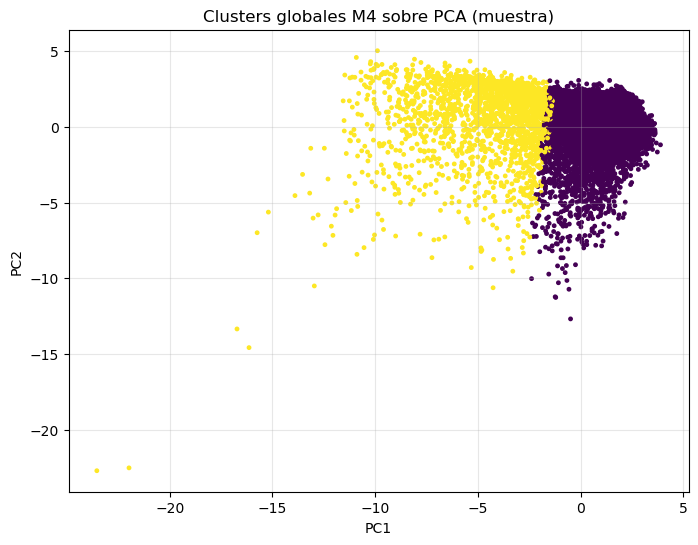


Archivo guardado: features_m4_all_v2_clustered_minibatch.xlsx


In [8]:
# Importa el módulo os para interactuar con variables de entorno y rutas del sistema.
import os

# Importa numpy para operaciones numéricas y manejo eficiente de arreglos.
import numpy as np

# Importa pandas para leer, manipular y guardar tablas de datos.
import pandas as pd

# Importa matplotlib para hacer gráficas.
import matplotlib.pyplot as plt

# Importa el imputador simple de scikit-learn.
# Lo usaremos para rellenar valores faltantes.
from sklearn.impute import SimpleImputer

# Importa StandardScaler para estandarizar las variables.
from sklearn.preprocessing import StandardScaler

# Importa VarianceThreshold para eliminar variables con varianza cero.
from sklearn.feature_selection import VarianceThreshold

# Importa PCA para reducción de dimensión.
from sklearn.decomposition import PCA

# Importa MiniBatchKMeans, una versión eficiente de KMeans para datasets grandes.
from sklearn.cluster import MiniBatchKMeans

# Importa dos métricas internas de clustering:
# - silhouette_score
# - davies_bouldin_score
from sklearn.metrics import silhouette_score, davies_bouldin_score


# =========================================================
# CONTROL DE HILOS / THREADS
# =========================================================

# Limita a 1 el número de hilos usados por OpenBLAS.
# Ayuda a evitar sobrecarga o conflictos en entornos locales.
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# Limita a 1 el número de hilos para OpenMP.
os.environ["OMP_NUM_THREADS"] = "1"

# Limita a 1 el número de hilos de MKL (Intel Math Kernel Library).
os.environ["MKL_NUM_THREADS"] = "1"

# Limita a 1 el número de hilos para VECLIB (backend numérico de macOS).
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"

# Limita a 1 el número de hilos para NUMEXPR.
os.environ["NUMEXPR_NUM_THREADS"] = "1"

# Permite coexistencia de librerías OpenMP duplicadas en ciertos entornos.
# Útil especialmente en macOS o notebooks donde a veces hay conflictos.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


# =========================================================
# ARCHIVOS DE ENTRADA Y SALIDA
# =========================================================

# Archivo Excel que contiene todas las features globales de M4 ya unificadas.
archivo_features = "features_m4_all_v2.xlsx"

# Archivo Excel de salida donde se guardará:
# - el cluster asignado a cada serie
# - métricas de K
# - resumen de clusters
archivo_salida = "features_m4_all_v2_clustered_minibatch.xlsx"


# =========================================================
# LISTA DE FEATURES QUE SE USARÁN PARA CLUSTERING
# =========================================================

# Lista de nombres de columnas que representan características estructurales
# previamente extraídas para cada serie de tiempo.
FEATURES_CLUSTER_V2 = [
    "z_skew","z_kurtosis","z_entropy","z_spectral_entropy",
    "z_outlier_ratio","z_turning_points_ratio","z_hurst",
    "z_acf1","z_acf6","z_acf_freq","z_acf_decay",
    "z_trend_linearity_r2","z_curvature_gain","z_trend_slope",
    "trend_strength","seasonal_strength",
    "dominant_frequency","dominant_energy_ratio",
    "adf_pvalue","kpss_pvalue","stationarity_conflict",
    "diff_var_ratio","change_points_per_length",
    "diff_skew","diff_kurtosis","diff_entropy",
    "diff_turning_points_ratio","robust_entropy","robust_outlier_ratio",
]


# =========================================================
# HIPERPARÁMETROS GENERALES
# =========================================================

# Semilla aleatoria para reproducibilidad.
RANDOM_STATE = 42

# Número máximo de series a usar para seleccionar K.
# Ojo: solo para selección de K, no para entrenar el modelo final.
N_SAMPLE = 30000

# Rango de K a evaluar: 2, 3, ..., 9
K_RANGE = range(2, 10)

# Tamaño de minibatch para MiniBatchKMeans.
BATCH_SIZE = 2048


# =========================================================
# CARGA DEL DATASET GLOBAL
# =========================================================

# Lee el archivo Excel con todas las features globales.
df = pd.read_excel(archivo_features)

# Imprime las dimensiones del dataset original.
print("Shape original:", df.shape)


# =========================================================
# SELECCIÓN DE FEATURES DISPONIBLES
# =========================================================

# De la lista teórica FEATURES_CLUSTER_V2,
# nos quedamos solo con las que realmente existan en el DataFrame.
features_disponibles = [c for c in FEATURES_CLUSTER_V2 if c in df.columns]

# Construimos un DataFrame solo con esas columnas.
X_df = df[features_disponibles].copy()

# Reemplazamos valores inf y -inf por NaN para evitar errores.
X_df = X_df.replace([np.inf, -np.inf], np.nan)

# Eliminamos columnas que estén completamente vacías.
X_df = X_df.dropna(axis=1, how="all")


# =========================================================
# ELIMINACIÓN DE VARIABLES CON VARIANZA CERO
# =========================================================

# Crea un selector que elimina columnas con varianza exactamente cero.
selector_var = VarianceThreshold(threshold=0.0)

# Para poder calcular varianza, primero imputamos temporalmente
# con la mediana de cada columna.
selector_var.fit(X_df.fillna(X_df.median(numeric_only=True)))

# Extraemos las columnas que sí sobrevivieron al filtro.
cols_var = X_df.columns[selector_var.get_support()]

# Reemplazamos X_df por la versión filtrada.
X_df = X_df[cols_var].copy()

# Imprime cuántas features quedaron.
print("Features usadas:", len(X_df.columns))

# Imprime cuáles columnas quedaron finalmente.
print("Columnas finales:", list(X_df.columns))


# =========================================================
# IMPUTACIÓN DE FALTANTES
# =========================================================

# Crea un imputador que rellena NaN con la mediana de cada columna.
imp = SimpleImputer(strategy="median")

# Aplica la imputación y devuelve una matriz numpy.
X_imp = imp.fit_transform(X_df)


# =========================================================
# ESTANDARIZACIÓN
# =========================================================

# Crea el estandarizador.
scaler = StandardScaler()

# Estandariza cada variable a media 0 y desviación estándar 1.
X_scaled = scaler.fit_transform(X_imp)


# =========================================================
# REDUCCIÓN DE DIMENSIÓN CON PCA
# =========================================================

# Crea el modelo PCA reteniendo componentes suficientes
# para explicar al menos el 90% de la varianza.
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)

# Ajusta PCA y transforma los datos al espacio reducido.
X_pca = pca.fit_transform(X_scaled)

# Imprime el número de dimensiones antes de PCA.
print("Dimensión original:", X_scaled.shape[1])

# Imprime el número de componentes retenidas después de PCA.
print("Dimensión PCA:", X_pca.shape[1])

# Imprime la varianza explicada acumulada final.
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())


# =========================================================
# MUESTRA PARA SELECCIÓN DE K
# =========================================================

# Crea un generador aleatorio reproducible.
rng = np.random.default_rng(RANDOM_STATE)

# Toma el mínimo entre N_SAMPLE y el número total de observaciones.
sample_size = min(N_SAMPLE, len(df))

# Elige índices aleatorios sin reemplazo.
sample_idx = rng.choice(len(df), size=sample_size, replace=False)

# Extrae solo esa submuestra en el espacio PCA.
X_pca_sample = X_pca[sample_idx]

# Imprime el tamaño de la muestra usada para seleccionar K.
print("Muestra para selección de k:", X_pca_sample.shape)


# =========================================================
# EVALUACIÓN DE DISTINTOS VALORES DE K
# =========================================================

# Lista vacía donde se guardarán los resultados por K.
resultados_k = []

# Recorre cada valor de K en el rango definido.
for k in K_RANGE:

    # Crea un modelo MiniBatchKMeans con K clusters.
    modelo_tmp = MiniBatchKMeans(
        n_clusters=k,              # número de clusters
        random_state=RANDOM_STATE, # semilla fija
        batch_size=BATCH_SIZE,     # tamaño de minibatch
        n_init=10                  # número de inicializaciones
    )

    # Ajusta el modelo sobre la muestra y obtiene etiquetas.
    labels_tmp = modelo_tmp.fit_predict(X_pca_sample)

    # Calcula métricas internas de clustering
    # y guarda resultados en la lista.
    resultados_k.append({
        "k": k,
        "metodo": "MiniBatchKMeans",
        "silhouette": silhouette_score(X_pca_sample, labels_tmp),
        "davies_bouldin": davies_bouldin_score(X_pca_sample, labels_tmp)
    })


# =========================================================
# ORDENACIÓN DE RESULTADOS POR CALIDAD
# =========================================================

# Convierte la lista de resultados a DataFrame
# y ordena por mejor silhouette y menor Davies-Bouldin.
res_k = pd.DataFrame(resultados_k).sort_values(
    by=["silhouette", "davies_bouldin"],
    ascending=[False, True]
)

# Imprime la tabla completa de resultados por K.
print("\nResultados por k:")
print(res_k)

# Toma el mejor K según la primera fila del DataFrame ordenado.
best_k = int(res_k.iloc[0]["k"])

# Imprime el mejor K encontrado.
print("\nMejor k:", best_k)


# =========================================================
# ENTRENAMIENTO FINAL SOBRE TODO EL DATASET
# =========================================================

# Crea el modelo final con el mejor K.
modelo_final = MiniBatchKMeans(
    n_clusters=best_k,            # mejor número de clusters
    random_state=RANDOM_STATE,    # semilla fija
    batch_size=BATCH_SIZE,        # minibatch
    n_init=20                     # más inicializaciones para el modelo final
)

# Ajusta el modelo final sobre TODO el dataset reducido
# y obtiene la etiqueta de cluster de cada serie.
labels_final = modelo_final.fit_predict(X_pca)

# Añade al DataFrame original una nueva columna "cluster".
df["cluster"] = labels_final


# =========================================================
# RESÚMENES POR CLUSTER
# =========================================================

# Cuenta cuántas series quedaron en cada cluster.
tam_clusters = df["cluster"].value_counts().sort_index()

# Calcula proporciones de series por cluster.
prop_clusters = df["cluster"].value_counts(normalize=True).sort_index()

# Calcula la media de cada feature dentro de cada cluster.
resumen_clusters = df.groupby("cluster")[X_df.columns].mean(numeric_only=True)

# Imprime tamaños absolutos por cluster.
print("\nTamaño de clusters:")
print(tam_clusters)

# Imprime proporciones por cluster.
print("\nProporción de clusters:")
print(prop_clusters)

# Imprime el resumen promedio de features por cluster.
print("\nResumen de clusters:")
print(resumen_clusters.T)


# =========================================================
# VISUALIZACIÓN EN PCA (MUESTRA)
# =========================================================

# Número máximo de puntos a graficar.
plot_n = min(10000, len(df))

# Selecciona índices aleatorios para graficar.
plot_idx = rng.choice(len(df), size=plot_n, replace=False)

# Crea figura.
plt.figure(figsize=(8, 6))

# Grafica los puntos en el plano PC1-PC2,
# coloreados por cluster.
plt.scatter(X_pca[plot_idx, 0], X_pca[plot_idx, 1], c=df.iloc[plot_idx]["cluster"], s=6)

# Título de la gráfica.
plt.title("Clusters globales M4 sobre PCA (muestra)")

# Etiqueta eje X.
plt.xlabel("PC1")

# Etiqueta eje Y.
plt.ylabel("PC2")

# Activa grid tenue.
plt.grid(True, alpha=0.3)

# Muestra la figura.
plt.show()


# =========================================================
# GUARDADO DE RESULTADOS EN EXCEL
# =========================================================

# Abre un ExcelWriter para guardar múltiples hojas.
with pd.ExcelWriter(archivo_salida, engine="openpyxl") as writer:

    # Guarda el dataset completo con cluster asignado.
    df.to_excel(writer, sheet_name="series_clustered", index=False)

    # Guarda la tabla de métricas por K.
    res_k.to_excel(writer, sheet_name="metricas_k", index=False)

    # Guarda el resumen promedio de features por cluster.
    resumen_clusters.to_excel(writer, sheet_name="resumen_clusters")

    # Guarda tamaños absolutos por cluster.
    tam_clusters.to_frame("n_series").to_excel(writer, sheet_name="tam_clusters")

    # Guarda proporciones por cluster.
    prop_clusters.to_frame("proporcion").to_excel(writer, sheet_name="prop_clusters")


# =========================================================
# MENSAJE FINAL
# =========================================================

# Confirma el nombre del archivo guardado.
print(f"\nArchivo guardado: {archivo_salida}")

In [38]:
print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

Varianza explicada acumulada: 0.9108969618055642


In [49]:
res_k = pd.DataFrame(resultados_k).sort_values(
    by=["silhouette", "davies_bouldin"],
    ascending=[False, True]
)

In [51]:
res_k_plot = res_k.sort_values("k")

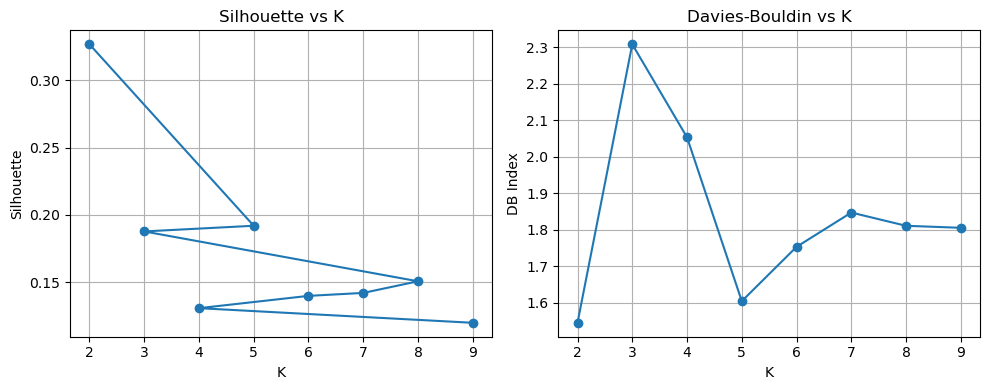

In [52]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(res_k["k"], res_k["silhouette"], marker="o")
plt.title("Silhouette vs K")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(res_k_plot["k"], res_k_plot["davies_bouldin"], marker="o")
plt.title("Davies-Bouldin vs K")
plt.xlabel("K")
plt.ylabel("DB Index")
plt.grid(True)

plt.tight_layout()
plt.show()

In [47]:
from sklearn.mixture import GaussianMixture

bic = []
aic = []

for k in range(2, 11):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_pca_sample)
    bic.append(gmm.bic(X_pca_sample))
    aic.append(gmm.aic(X_pca_sample))

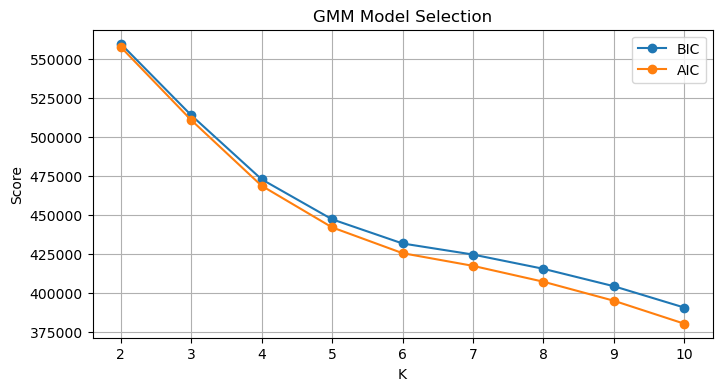

In [48]:
plt.figure(figsize=(8,4))

plt.plot(range(2,11), bic, marker="o", label="BIC")
plt.plot(range(2,11), aic, marker="o", label="AIC")

plt.title("GMM Model Selection")
plt.xlabel("K")
plt.ylabel("Score")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
# =========================================================
# LOADINGS DE LA PRIMERA COMPONENTE PRINCIPAL (PC1)
# =========================================================

# Los loadings son los coeficientes que indican cuánto contribuye
# cada feature original a la componente principal.
# pca.components_[0] corresponde a la PC1.
loadings_pc1 = pd.Series(
    pca.components_[0],
    index=X_df.columns,
    name="loading_pc1"
)

# Ordena las features por magnitud absoluta de contribución,
# de mayor a menor.
loadings_pc1_sorted = loadings_pc1.reindex(
    loadings_pc1.abs().sort_values(ascending=False).index
)

# Imprime todas las cargas ordenadas
print("\nLoadings de PC1 ordenados por magnitud absoluta:")
print(loadings_pc1_sorted)

# Extrae las 10 cargas más importantes
top10_loadings_pc1 = loadings_pc1_sorted.head(10)

print("\nTop 10 loadings de PC1:")
print(top10_loadings_pc1)

# Guarda los loadings en Excel si quieres documentarlos
loadings_pc1_sorted.to_frame().to_excel("pc1_loadings.xlsx", index=True)

print("\nArchivo guardado: pc1_loadings.xlsx")


Loadings de PC1 ordenados por magnitud absoluta:
z_acf1                       0.316514
diff_var_ratio              -0.314031
trend_strength               0.297520
dominant_energy_ratio        0.262108
z_acf_decay                  0.258926
z_acf_freq                   0.258506
z_spectral_entropy          -0.251219
z_acf6                       0.244407
z_trend_linearity_r2         0.244109
kpss_pvalue                 -0.216055
z_entropy                    0.196909
robust_entropy               0.196905
dominant_frequency          -0.185564
z_hurst                      0.180749
adf_pvalue                   0.177479
stationarity_conflict       -0.152791
z_kurtosis                  -0.150700
z_turning_points_ratio      -0.147706
z_skew                      -0.115947
z_outlier_ratio             -0.081306
robust_outlier_ratio        -0.081306
diff_turning_points_ratio   -0.080485
z_trend_slope                0.044998
change_points_per_length    -0.034284
z_curvature_gain            -0.015776


In [40]:
# =========================================================
# TABLA LIMPIA DE LOADINGS PARA DOCUMENTACIÓN
# =========================================================

tabla_loadings_pc1 = pd.DataFrame({
    "feature": loadings_pc1_sorted.index,
    "loading_pc1": loadings_pc1_sorted.values,
    "abs_loading": loadings_pc1_sorted.abs().values,
    "direccion": ["positiva" if x > 0 else "negativa" for x in loadings_pc1_sorted.values]
})

print("\nTabla de loadings de PC1:")
print(tabla_loadings_pc1.head(15))

tabla_loadings_pc1.to_excel("tabla_loadings_pc1.xlsx", index=False)

print("\nArchivo guardado: tabla_loadings_pc1.xlsx")


Tabla de loadings de PC1:
                  feature  loading_pc1  abs_loading direccion
0                  z_acf1     0.316514     0.316514  positiva
1          diff_var_ratio    -0.314031     0.314031  negativa
2          trend_strength     0.297520     0.297520  positiva
3   dominant_energy_ratio     0.262108     0.262108  positiva
4             z_acf_decay     0.258926     0.258926  positiva
5              z_acf_freq     0.258506     0.258506  positiva
6      z_spectral_entropy    -0.251219     0.251219  negativa
7                  z_acf6     0.244407     0.244407  positiva
8    z_trend_linearity_r2     0.244109     0.244109  positiva
9             kpss_pvalue    -0.216055     0.216055  negativa
10              z_entropy     0.196909     0.196909  positiva
11         robust_entropy     0.196905     0.196905  positiva
12     dominant_frequency    -0.185564     0.185564  negativa
13                z_hurst     0.180749     0.180749  positiva
14             adf_pvalue     0.177479     

In [41]:
# =========================================================
# CORRELACIÓN ENTRE PC1 Y FEATURES ORIGINALES
# =========================================================

# Proyección de cada serie en PC1
pc1_scores = pd.Series(X_pca[:, 0], name="pc1_score")

# DataFrame con features finales usadas
df_corr_pc1 = X_df.copy().reset_index(drop=True)
df_corr_pc1["pc1_score"] = pc1_scores.values

# Calcula correlaciones con PC1
corr_with_pc1 = df_corr_pc1.corr(numeric_only=True)["pc1_score"].drop("pc1_score")

# Ordena por magnitud absoluta
corr_with_pc1_sorted = corr_with_pc1.reindex(
    corr_with_pc1.abs().sort_values(ascending=False).index
)

print("\nCorrelaciones entre PC1 y features:")
print(corr_with_pc1_sorted)

corr_with_pc1_sorted.to_frame("corr_pc1").to_excel("pc1_feature_correlations.xlsx")

print("\nArchivo guardado: pc1_feature_correlations.xlsx")


Correlaciones entre PC1 y features:
trend_strength               0.904270
z_acf1                       0.884861
diff_var_ratio              -0.877918
dominant_energy_ratio        0.732761
z_acf_decay                  0.723864
z_acf_freq                   0.722690
z_spectral_entropy          -0.702318
z_acf6                       0.684772
z_trend_linearity_r2         0.682440
kpss_pvalue                 -0.604012
z_entropy                    0.550486
robust_entropy               0.550476
z_hurst                      0.520561
dominant_frequency          -0.518771
adf_pvalue                   0.496168
stationarity_conflict       -0.427149
z_kurtosis                  -0.421302
z_turning_points_ratio      -0.412933
z_skew                      -0.324146
z_outlier_ratio             -0.227303
robust_outlier_ratio        -0.227303
diff_turning_points_ratio   -0.225007
z_trend_slope                0.125797
change_points_per_length    -0.095845
z_curvature_gain            -0.044103
seasonal_stre

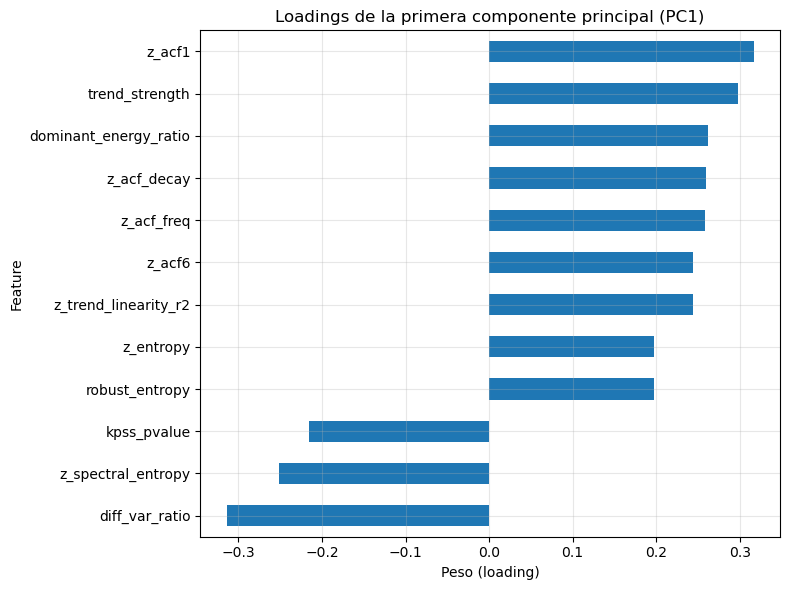

In [42]:
# ============================================
# LOADINGS DE PC1
# ============================================

# Extrae loadings de la primera componente
loadings_pc1 = pd.Series(
    pca.components_[0],
    index=X_df.columns
)

# Ordena por valor absoluto (más importantes primero)
loadings_sorted = loadings_pc1.reindex(
    loadings_pc1.abs().sort_values(ascending=False).index
)

# Toma top 12 para visualización
top_n = 12
loadings_top = loadings_sorted.head(top_n)

# ============================================
# GRAFICA
# ============================================

plt.figure(figsize=(8,6))

loadings_top.sort_values().plot(
    kind="barh"
)

plt.title("Loadings de la primera componente principal (PC1)")
plt.xlabel("Peso (loading)")
plt.ylabel("Feature")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pc1_loadings.png", dpi=300)
plt.show()

# Funciones de complejidad

In [62]:
import numpy as np
import pandas as pd
from math import factorial
from collections import Counter


def permutation_entropy(x, m=3, tau=1, normalize=True):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < (m - 1) * tau + 1:
        return np.nan

    patterns = []
    for i in range(n - (m - 1) * tau):
        window = x[i:i + m * tau:tau]
        pattern = tuple(np.argsort(window))
        patterns.append(pattern)

    counts = Counter(patterns)
    probs = np.array(list(counts.values()), dtype=float)
    probs /= probs.sum()

    # 🔥 FIX CLAVE
    probs = probs[probs > 0]

    pe = -np.sum(probs * np.log(probs))

    if normalize:
        pe /= np.log(factorial(m))

    # 🔥 seguridad numérica
    pe = max(pe, 0)

    return pe


def sample_entropy(x, m=2, r=None):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < m + 2:
        return np.nan

    if r is None:
        r = 0.2 * np.std(x)
    if r == 0:
        return 0.0

    def _count_matches(mm):
        count = 0
        total = 0
        for i in range(n - mm):
            template = x[i:i+mm]
            for j in range(i + 1, n - mm + 1):
                window = x[j:j+mm]
                if np.max(np.abs(template - window)) <= r:
                    count += 1
                total += 1
        return count, total

    count_m, total_m = _count_matches(m)
    count_m1, total_m1 = _count_matches(m + 1)

    if total_m == 0 or total_m1 == 0 or count_m == 0 or count_m1 == 0:
        return np.nan

    phi_m = count_m / total_m
    phi_m1 = count_m1 / total_m1
    return -np.log(phi_m1 / phi_m)


def lz_complexity_binary(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return np.nan

    median = np.median(x)
    s = ''.join('1' if v > median else '0' for v in x)

    i, l, k = 0, 1, 1
    c = 1

    while True:
        if l + k > n or i + k > n:
            c += 1
            break

        if s[i:i+k] == s[l:l+k]:
            k += 1
        else:
            i += 1
            if i == l:
                c += 1
                l += k
                if l >= n:
                    break
                i = 0
                k = 1

    return c / (n / np.log2(n)) if n > 1 else np.nan

In [63]:
M4_EVAL_CONFIG = {
    "Yearly":    {"train_file": "Yearly-train.csv",    "h": 6},
    "Quarterly": {"train_file": "Quarterly-train.csv", "h": 8},
    "Monthly":   {"train_file": "Monthly-train.csv",   "h": 18},
    "Weekly":    {"train_file": "Weekly-train.csv",    "h": 13},
    "Daily":     {"train_file": "Daily-train.csv",     "h": 14},
    "Hourly":    {"train_file": "Hourly-train.csv",    "h": 48},
}

def load_m4_train_series(train_file):
    df_train = pd.read_csv(train_file)

    if df_train.columns[0].startswith("Unnamed"):
        df_train = df_train.iloc[:, 1:]

    id_col = df_train.columns[0]

    series_dict = {}
    for _, row in df_train.iterrows():
        serie_id = str(row[id_col])
        values = pd.to_numeric(row.iloc[1:], errors="coerce").dropna().astype(float).values
        series_dict[serie_id] = values

    return series_dict

In [ ]:
MAX_SERIES_PER_CATEGORY_ENT = 1000  # cambia luego a None si quieres correr todo

resultados_entropy = []

for category_name, cfg in M4_EVAL_CONFIG.items():
    print(f"\nProcesando categoría: {category_name}")

    series_dict = load_m4_train_series(cfg["train_file"])

    df_cat = df_features[df_features["category"] == category_name].copy()

    if MAX_SERIES_PER_CATEGORY_ENT is not None:
        df_cat = df_cat.head(MAX_SERIES_PER_CATEGORY_ENT)

    print("Series a procesar:", len(df_cat))

    for _, row in df_cat.iterrows():
        serie_id = str(row["serie"])
        x = series_dict.get(serie_id, None)

        if x is None or len(x) < 10:
            resultados_entropy.append({
                "serie": serie_id,
                "category": category_name,
                "perm_entropy": np.nan,
                "sample_entropy": np.nan,
                "lz_complexity": np.nan
            })
            continue

        resultados_entropy.append({
            "serie": serie_id,
            "category": category_name,
            "perm_entropy": permutation_entropy(x, m=3, tau=1, normalize=True),
            "sample_entropy": sample_entropy(x, m=2),
            "lz_complexity": lz_complexity_binary(x)
        })

df_entropy = pd.DataFrame(resultados_entropy)

print("\nShape df_entropy:", df_entropy.shape)
print(df_entropy.head())


Procesando categoría: Yearly
Series a procesar: 1000

Procesando categoría: Quarterly
Series a procesar: 1000

Procesando categoría: Monthly
Series a procesar: 1000


In [ ]:
df_features_entropy = df_features.merge(
    df_entropy,
    on=["serie", "category"],
    how="left"
)

print(df_features_entropy[[
    "serie", "category", "complexity_index",
    "perm_entropy", "sample_entropy", "lz_complexity",
    "error_naive_smape"
]].head())

In [ ]:
cols_eval = [
    "complexity_index",
    "perm_entropy",
    "sample_entropy",
    "lz_complexity",
    "error_naive_smape"
]

corr_global = df_features_entropy[cols_eval].corr(numeric_only=True)
print(corr_global)

In [ ]:
for cat in df_features_entropy["category"].dropna().unique():
    sub = df_features_entropy[df_features_entropy["category"] == cat].copy()

    print(f"\n===== {cat} =====")
    print(sub[[
        "complexity_index",
        "perm_entropy",
        "sample_entropy",
        "lz_complexity",
        "error_naive_smape"
    ]].corr(numeric_only=True))

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df_reg = df_features_entropy.dropna(subset=[
    "complexity_index",
    "perm_entropy",
    "sample_entropy",
    "lz_complexity",
    "error_naive_smape"
]).copy()

y = df_reg["error_naive_smape"].values

# Modelo 1: solo complexity_index
X1 = df_reg[["complexity_index"]].values
m1 = LinearRegression().fit(X1, y)
r2_1 = r2_score(y, m1.predict(X1))

# Modelo 2: solo entropías
X2 = df_reg[["perm_entropy", "sample_entropy", "lz_complexity"]].values
m2 = LinearRegression().fit(X2, y)
r2_2 = r2_score(y, m2.predict(X2))

# Modelo 3: complexity_index + entropías
X3 = df_reg[["complexity_index", "perm_entropy", "sample_entropy", "lz_complexity"]].values
m3 = LinearRegression().fit(X3, y)
r2_3 = r2_score(y, m3.predict(X3))

print("R2 solo complexity_index:", r2_1)
print("R2 solo entropías:", r2_2)
print("R2 complexity_index + entropías:", r2_3)

print("\nCoeficientes modelo 3:")
print(pd.Series(
    m3.coef_,
    index=["complexity_index", "perm_entropy", "sample_entropy", "lz_complexity"]
))

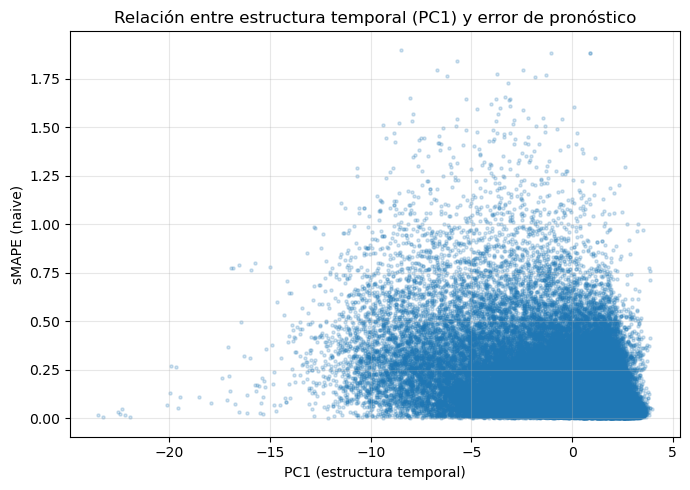

In [43]:
# ============================================
# SCATTER: PC1 vs sMAPE
# ============================================

# PC1 (ya lo tienes en X_pca)
pc1 = X_pca[:, 0]

# Asegúrate de usar el mismo orden que df_features
df_plot = df_features.copy()
df_plot = df_plot.reset_index(drop=True)

df_plot["pc1"] = pc1

# Scatter
plt.figure(figsize=(7,5))

plt.scatter(
    df_plot["pc1"],
    df_plot["error_naive_smape"],
    alpha=0.2,
    s=5
)

plt.xlabel("PC1 (estructura temporal)")
plt.ylabel("sMAPE (naive)")
plt.title("Relación entre estructura temporal (PC1) y error de pronóstico")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("pc1_vs_error.png", dpi=300)
plt.show()

In [44]:
# ============================================
# CORRELACIÓN
# ============================================

corr = np.corrcoef(df_plot["pc1"], df_plot["error_naive_smape"])[0,1]

print("Correlación PC1 vs sMAPE:", corr)

Correlación PC1 vs sMAPE: -0.404934248854456


In [45]:
# correlación por frecuencia
df_plot.groupby("category").apply(
    lambda g: np.corrcoef(g["pc1"], g["error_naive_smape"])[0,1]
)

category
Daily       -0.018816
Hourly      -0.735855
Monthly     -0.442295
Quarterly   -0.413849
Weekly      -0.532814
Yearly      -0.263671
dtype: float64

# Análisis de sensibilidad respecto a la frecuencia de las series

Una cuestión clave en el análisis de colecciones heterogéneas de series de tiempo es determinar en qué medida la estructura observada en el espacio de características está influenciada por la frecuencia de muestreo.

En la competencia M4, las series provienen de distintas frecuencias (anual, trimestral, mensual, semanal, diaria y horaria), lo cual introduce una fuente adicional de heterogeneidad que podría afectar los resultados del clustering.

---

## Incorporación de la frecuencia como variable

Para evaluar este efecto, se introduce una variable adicional derivada de la frecuencia:

    freq_log = log(1 + freq)

Esta transformación tiene dos objetivos:

- reducir la asimetría en la distribución de frecuencias,
- evitar que diferencias de escala dominen el análisis.

De esta manera, el espacio de características se amplía incluyendo información explícita sobre la frecuencia de cada serie.

---

## Procedimiento experimental

El pipeline se mantiene sin cambios respecto al análisis base:

- imputación por mediana,
- eliminación de variables con varianza cero,
- estandarización,
- reducción de dimensión mediante PCA (reteniendo ~90% de varianza),
- clustering con MiniBatchKMeans,
- evaluación mediante Silhouette y Davies-Bouldin.

La selección de K se realiza sobre una submuestra aleatoria para reducir el costo computacional.

---

## Objetivo del análisis

Este experimento busca responder:

> ¿La estructura observada en el espacio de características es intrínseca a las series o está influenciada por la frecuencia de muestreo?

---

## Escenarios posibles

Se consideran dos casos:

### 1. Dependencia de la frecuencia

Si al incluir `freq_log`:

- cambian los clusters,
- mejoran significativamente las métricas,

entonces parte de la estructura detectada estaba explicada por la frecuencia.

---

### 2. Independencia estructural

Si los resultados:

- permanecen estables,
- no cambian significativamente las métricas,

entonces la estructura observada es robusta y responde a propiedades internas de las series.

---

## Implicación metodológica

Este análisis funciona como una prueba de robustez.

Permite verificar que el índice de complejidad estructural:

- no está sesgado por la frecuencia,
- captura propiedades dinámicas intrínsecas,
- es comparable entre series de distinta naturaleza.

---

## Interpretación dentro del trabajo

Este experimento es clave porque valida si el resultado principal del estudio:

> la existencia de un continuo de complejidad estructural

es realmente una propiedad del sistema o un artefacto de la mezcla de frecuencias.

En otras palabras, separa:

- señal estructural real  
de  
- efectos inducidos por la escala temporal

In [9]:
# Importa numpy, que usaremos para operaciones numéricas,
# manejo de arreglos y funciones como log1p.
import numpy as np

# Importa pandas, que usaremos para leer el archivo Excel
# y manipular el dataset de features.
import pandas as pd

# Importa VarianceThreshold, que elimina variables con varianza cero.
from sklearn.feature_selection import VarianceThreshold

# Importa SimpleImputer, que se usará para rellenar valores faltantes.
from sklearn.impute import SimpleImputer

# Importa StandardScaler, que estandariza las variables.
from sklearn.preprocessing import StandardScaler

# Importa PCA para reducción de dimensión.
from sklearn.decomposition import PCA

# Importa MiniBatchKMeans, una versión eficiente de KMeans para datasets grandes.
from sklearn.cluster import MiniBatchKMeans

# Importa métricas internas de clustering.
# - silhouette_score: mide cohesión y separación
# - davies_bouldin_score: mide compacidad y separación entre clusters
from sklearn.metrics import silhouette_score, davies_bouldin_score


# =========================================================
# CARGA DEL ARCHIVO GLOBAL DE FEATURES
# =========================================================

# Nombre del archivo Excel que contiene todas las features globales de M4.
archivo_features = "features_m4_all_v2.xlsx"

# Lee el archivo Excel y lo guarda en un DataFrame.
df = pd.read_excel(archivo_features)


# =========================================================
# CREACIÓN DE UNA NUEVA FEATURE: freq_log
# =========================================================

# Crea una nueva columna llamada "freq_log" aplicando log(1 + freq)
# a la variable frecuencia.
# Esto reduce la diferencia de escala entre frecuencias como:
# 1, 4, 12, 52, 24, etc.
df["freq_log"] = np.log1p(df["freq"])


# =========================================================
# ACTUALIZACIÓN DE LA LISTA DE FEATURES
# =========================================================

# Toma la lista original FEATURES_CLUSTER_V2
# y le agrega una variable nueva: "freq_log".
FEATURES_CLUSTER_V2_PLUS = FEATURES_CLUSTER_V2 + ["freq_log"]


# =========================================================
# SELECCIÓN DE FEATURES DISPONIBLES
# =========================================================

# Se queda solo con los nombres de columnas que realmente existen en el DataFrame.
features_disponibles = [c for c in FEATURES_CLUSTER_V2_PLUS if c in df.columns]

# Construye un DataFrame solo con esas columnas.
X_df = df[features_disponibles].copy()


# =========================================================
# LIMPIEZA DE VALORES PROBLEMÁTICOS
# =========================================================

# Reemplaza inf y -inf por NaN.
X_df = X_df.replace([np.inf, -np.inf], np.nan)

# Elimina columnas que estén completamente vacías.
X_df = X_df.dropna(axis=1, how="all")


# =========================================================
# ELIMINACIÓN DE VARIABLES CON VARIANZA CERO
# =========================================================

# Crea un selector que elimina variables cuya varianza sea cero.
selector_var = VarianceThreshold(threshold=0.0)

# Para poder calcular la varianza, primero rellena faltantes
# con la mediana de cada columna.
selector_var.fit(X_df.fillna(X_df.median(numeric_only=True)))

# Obtiene los nombres de las columnas que sobreviven al filtro.
cols_var = X_df.columns[selector_var.get_support()]

# Reemplaza X_df por la versión filtrada.
X_df = X_df[cols_var].copy()


# =========================================================
# IMPUTACIÓN DE VALORES FALTANTES
# =========================================================

# Crea un imputador que rellena NaN con la mediana de cada columna.
imp = SimpleImputer(strategy="median")

# Aplica la imputación.
# El resultado es una matriz numpy.
X_imp = imp.fit_transform(X_df)


# =========================================================
# ESTANDARIZACIÓN
# =========================================================

# Crea el estandarizador.
scaler = StandardScaler()

# Estandariza cada columna:
# media = 0
# desviación estándar = 1
X_scaled = scaler.fit_transform(X_imp)


# =========================================================
# PCA
# =========================================================

# Crea el modelo PCA reteniendo suficientes componentes
# para explicar al menos el 90% de la varianza.
pca = PCA(n_components=0.90, random_state=42)

# Ajusta PCA y transforma los datos al espacio reducido.
X_pca = pca.fit_transform(X_scaled)


# =========================================================
# SUBMUESTRA PARA ELEGIR K
# =========================================================

# Crea un generador aleatorio reproducible.
rng = np.random.default_rng(42)

# Define el tamaño de muestra:
# usa 15000 o menos si el dataset tiene menos observaciones.
sample_size = min(15000, len(X_pca))

# Selecciona índices aleatorios sin reemplazo.
sample_idx = rng.choice(len(X_pca), size=sample_size, replace=False)

# Extrae solo la submuestra en el espacio PCA.
X_pca_sample = X_pca[sample_idx]


# =========================================================
# EVALUACIÓN DE DISTINTOS K
# =========================================================

# Lista vacía donde se guardarán las métricas para cada valor de K.
resultados_k = []

# Recorre K = 2, 3, ..., 9
for k in range(2, 10):

    # Crea un modelo MiniBatchKMeans con k clusters.
    modelo = MiniBatchKMeans(
        n_clusters=k,      # número de clusters
        random_state=42,   # semilla fija
        batch_size=2048,   # tamaño del minibatch
        n_init=10          # número de inicializaciones
    )

    # Ajusta el modelo sobre la muestra PCA
    # y obtiene la etiqueta de cluster de cada punto.
    labels = modelo.fit_predict(X_pca_sample)

    # Guarda las métricas de calidad interna para este K.
    resultados_k.append({
        "k": k,
        "metodo": "MiniBatchKMeans",
        "silhouette": silhouette_score(X_pca_sample, labels),
        "davies_bouldin": davies_bouldin_score(X_pca_sample, labels)
    })


# =========================================================
# CONSTRUCCIÓN DE TABLA FINAL DE RESULTADOS
# =========================================================

# Convierte la lista de resultados a DataFrame
# y la ordena por:
# 1) silhouette más alto
# 2) davies_bouldin más bajo
res_k = pd.DataFrame(resultados_k).sort_values(
    by=["silhouette", "davies_bouldin"],
    ascending=[False, True]
)

# Imprime la tabla final ordenada.
print(res_k)

   k           metodo  silhouette  davies_bouldin
0  2  MiniBatchKMeans    0.326773        1.544518
3  5  MiniBatchKMeans    0.191876        1.603860
1  3  MiniBatchKMeans    0.187658        2.308788
6  8  MiniBatchKMeans    0.150604        1.810688
5  7  MiniBatchKMeans    0.141963        1.846983
4  6  MiniBatchKMeans    0.139764        1.752908
2  4  MiniBatchKMeans    0.130626        2.053381
7  9  MiniBatchKMeans    0.119754        1.805153


# Interpretación del Clustering Global en M4

## 1. Estabilidad del modelo ante la inclusión de la frecuencia

Se realizó una comparación entre dos escenarios:

- Clustering utilizando únicamente características estadísticas y dinámicas de las series.
- Clustering incorporando adicionalmente la variable `freq_log` (logaritmo de la frecuencia temporal).

Los resultados obtenidos fueron:

- **Sin `freq_log`**: silhouette ≈ 0.336  
- **Con `freq_log`**: silhouette ≈ 0.326  

La diferencia es marginal.

### Conclusión

La inclusión de la frecuencia **no altera significativamente la estructura del clustering**, lo que implica que:

> La segmentación no está dominada por la granularidad temporal (yearly, monthly, daily, etc.), sino por propiedades intrínsecas de las series.

---

## 2. Naturaleza de la estructura encontrada

El modelo identifica consistentemente:

- **k = 2** como el mejor número de clusters
- Una separación clara en el espacio reducido (PCA), principalmente en la primera componente (PC1)

Sin embargo, el análisis geométrico del espacio muestra que:

- No existen múltiples grupos bien separados
- Existe una **distribución continua a lo largo de PC1**

### Interpretación

El clustering no revela clases discretas independientes, sino:

> Un **continuo de complejidad dinámica** de las series de tiempo.

---



## 3. Significado de la primera componente principal (PC1)

La primera componente principal (PC1) concentra la mayor parte de la variabilidad del sistema y actúa como un eje latente que organiza las series de tiempo en el espacio reducido.

Este eje puede interpretarse como un gradiente continuo de complejidad dinámica:

$$
\text{Alta estructura} \;\;\longleftrightarrow\;\; \text{Alta irregularidad}
$$

### Interpretación de los extremos

**Extremo izquierdo (valores bajos de PC1):**
- Alta autocorrelación (ACF elevada)
- Fuerte tendencia
- Baja entropía
- Alta persistencia (Hurst mayor)
- Comportamiento suave y regular

$$
\Rightarrow \text{Series altamente estructuradas y predecibles}
$$

---

**Extremo derecho (valores altos de PC1):**
- Alta entropía
- Mayor número de puntos de cambio
- Mayor proporción de turning points
- Mayor varianza en diferencias
- Menor autocorrelación

$$
\Rightarrow \text{Series complejas, irregulares y difíciles de predecir}
$$

---

### Interpretación global

La PC1 no representa una variable observable directa, sino una combinación lineal de múltiples características:

$$
\text{PC1} = \sum_{j=1}^{p} w_j \, x_j
$$

donde:
- $ x_j $ son las features (entropía, ACF, Hurst, etc.)
- $ w_j $ son los pesos del PCA

Por lo tanto:

> La PC1 captura una dimensión latente que sintetiza simultáneamente información de dependencia temporal, complejidad y estructura estadística.

---

### Implicación clave

Este resultado sugiere que:

> La diversidad de series en M4 puede explicarse, en gran medida, por una sola dimensión dominante que mide su grado de complejidad dinámica.

Esto justifica el uso de la PC1 como un **índice continuo de dificultad de pronóstico**.

---

## 4. Reinterpretación del clustering

El resultado obtenido con $ k = 2 $ no debe interpretarse como la existencia de dos clases naturales independientes de series de tiempo, sino como una partición inducida sobre una estructura subyacente continua.

En particular, el análisis del espacio reducido mediante PCA muestra que la separación entre clusters ocurre principalmente a lo largo de la primera componente principal (PC1), lo cual indica que:

> El clustering está segmentando un eje latente continuo en lugar de descubrir múltiples grupos discretos bien separados.

Esto implica que:

- La estructura subyacente del problema es esencialmente **unidimensional**
- El algoritmo de clustering actúa como una **discretización de un continuo**
- La separación observada responde a diferencias graduales en el comportamiento de las series, no a categorías cualitativamente distintas

---

## 5. Implicaciones metodológicas

Este hallazgo tiene implicaciones relevantes para el análisis de series de tiempo en el contexto de la competencia M4:

- Las series no constituyen un conjunto homogéneo, sino que presentan distintos niveles de complejidad dinámica
- Existe una dimensión dominante que explica gran parte de la variabilidad observada
- La dificultad del problema de pronóstico no es uniforme, sino que depende de la posición de cada serie en dicho continuo

En consecuencia:

> El uso de una única metodología de pronóstico para todas las series puede ser subóptimo, dado que diferentes regiones del espacio presentan características dinámicas distintas.

---

## 6. Propuesta: Índice de Complejidad

Dado que la primera componente principal (PC1) captura la mayor parte de la variabilidad estructural del sistema, se propone utilizarla como un indicador continuo del nivel de complejidad de cada serie.

En términos computacionales:

```python
df$$"complexity_index"$$ = X_pca$$:, 0$$

In [10]:
# Importa el estandarizador
from sklearn.preprocessing import StandardScaler

# Toma la primera componente principal (PC1),
# le cambia el signo para que valores altos representen mayor complejidad,
# la convierte en matriz columna,
# la estandariza a media 0 y desviación estándar 1,
# y guarda el resultado en una nueva columna del DataFrame.
df["complexity_index"] = StandardScaler().fit_transform((-X_pca[:, 0]).reshape(-1, 1))

# Construcción del índice de complejidad estructural

Con el objetivo de sintetizar la información contenida en el espacio de características en una sola dimensión interpretable, se define un índice de complejidad estructural a partir de la primera componente principal del análisis PCA.

---

## Definición

Sea:

- $ \mathbf{Z} \in \mathbb{R}^{N \times q} $: la matriz de datos en el espacio reducido mediante PCA,
- $ z^{(1)}_i $: la proyección de la serie $ i $ sobre la primera componente principal.

Se define el índice de complejidad como:

$$
\text{ComplexityIndex}_i = -z^{(1)}_i
$$

El signo negativo se introduce con fines interpretativos, de modo que valores mayores del índice correspondan a series más complejas.

---

## Estandarización

Para facilitar la comparación entre series y permitir interpretaciones relativas, el índice se estandariza:

$$
\widetilde{C}_i = \frac{\text{ComplexityIndex}_i - \mu_C}{\sigma_C}
$$

donde:

- $ \mu_C $: media del índice en la muestra,
- $ \sigma_C $: desviación estándar.

Esta transformación produce una variable con media cero y varianza unitaria, preservando el orden relativo entre las series.

---

## Interpretación

El índice de complejidad no corresponde a una característica individual, sino a una combinación lineal de las variables originales:

$$
\text{ComplexityIndex}_i = -\sum_{j=1}^{p} w_{1j} z_{ij}
$$

donde:

- $ w_{1j} $: cargas de la primera componente principal,
- $ z_{ij} $: características estandarizadas.

En consecuencia, el índice captura simultáneamente múltiples dimensiones de la dinámica temporal.

---

## Significado estructural

Empíricamente, el índice refleja un continuo entre dos extremos:

### Baja complejidad (valores bajos)

- alta autocorrelación,
- fuerte estructura de tendencia,
- patrones estacionales definidos,
- baja entropía,
- comportamiento regular.

---

### Alta complejidad (valores altos)

- baja dependencia temporal,
- alta entropía,
- mayor irregularidad,
- mayor variabilidad en diferencias,
- comportamiento cercano a ruido.

---

## Interpretación geométrica

Desde una perspectiva geométrica, la primera componente principal define el eje de mayor varianza en el espacio de características. El índice de complejidad corresponde a la coordenada de cada serie sobre este eje.

Esto implica que el conjunto de series no se organiza en grupos discretos, sino a lo largo de un gradiente continuo de complejidad estructural.

---

## Implicación metodológica

La construcción de este índice permite transformar un problema de alta dimensión en una representación unidimensional interpretable, facilitando:

- el análisis comparativo entre series,
- la segmentación por niveles de complejidad,
- la evaluación del desempeño de modelos de pronóstico en función de la estructura de la serie.

En este sentido, el índice de complejidad constituye una herramienta central para reinterpretar el problema de forecasting como un fenómeno condicionado por la estructura interna de las series.

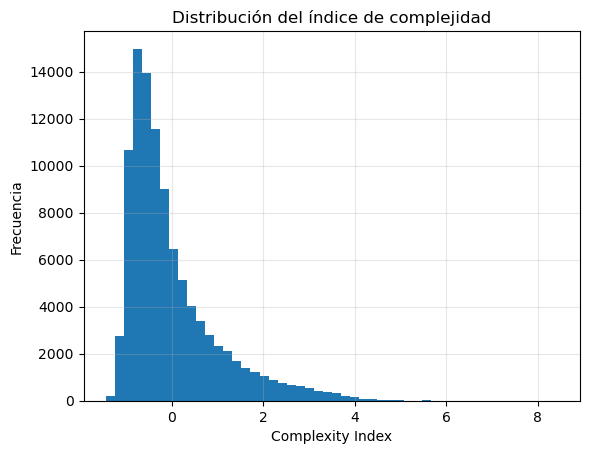

In [11]:
# Genera un histograma de la columna "complexity_index" del DataFrame.
# Divide el rango de valores en 50 intervalos (bins),
# lo que permite ver con mayor detalle la forma de la distribución.
df["complexity_index"].hist(bins=50)

# Establece el título del gráfico.
# Esto describe qué se está visualizando: la distribución del índice de complejidad.
plt.title("Distribución del índice de complejidad")

# Define la etiqueta del eje horizontal (x),
# que representa los valores del índice de complejidad.
plt.xlabel("Complexity Index")

# Define la etiqueta del eje vertical (y),
# que indica la frecuencia (número de series) en cada intervalo del histograma.
plt.ylabel("Frecuencia")

# Activa la cuadrícula del gráfico para facilitar la lectura visual.
# alpha=0.3 hace que la cuadrícula sea tenue (transparente),
# evitando que distraiga de las barras del histograma.
plt.grid(True, alpha=0.3)

<Axes: title={'center': 'complexity_index'}, xlabel='cluster'>

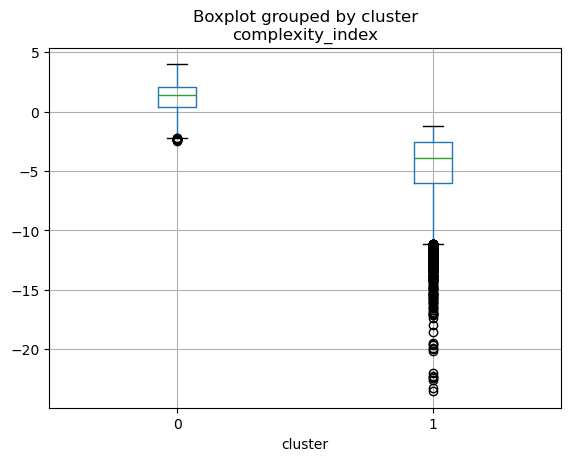

In [12]:
# Asigna a cada fila del DataFrame (cada serie) su etiqueta de cluster.
# labels_final es un vector con valores como 0, 1, ..., K-1,
# resultado del algoritmo de clustering (por ejemplo, KMeans).
df["cluster"] = labels_final


# Crea una nueva columna llamada "complexity_index"
# usando directamente la primera componente principal (PC1).
# X_pca[:, 0] es el valor de PC1 para cada serie.
# (Aquí NO estás estandarizando ni cambiando signo, solo copiando PC1)
df["complexity_index"] = X_pca[:, 0]


# Genera un boxplot (diagrama de caja) de "complexity_index"
# agrupado por la variable "cluster".
# Esto permite ver la distribución del índice dentro de cada cluster.
df.boxplot(column="complexity_index", by="cluster")

# Análisis de la distribución del índice de complejidad y su relación con el clustering

Con el fin de comprender la estructura del espacio de características y la naturaleza de la partición obtenida mediante clustering, se analizan dos visualizaciones complementarias:

1. la distribución global del índice de complejidad,
2. su comportamiento condicionado por los clústeres.

---

## Distribución global del índice de complejidad

El histograma del índice de complejidad permite analizar la forma de su distribución en el conjunto completo de series.

Empíricamente, se observa que:

- la distribución es continua,
- no presenta multimodalidad clara,
- no existen separaciones evidentes entre grupos.

Este comportamiento sugiere que las series no se organizan en clases discretas, sino que se distribuyen a lo largo de un continuo estructural.

En particular, la ausencia de múltiples picos bien definidos indica que no existen subpoblaciones naturalmente separadas en términos de complejidad, lo cual es consistente con la hipótesis de que la variabilidad del conjunto está gobernada por un eje latente dominante.

---

## Distribución del índice por clúster

El diagrama de cajas (boxplot) del índice de complejidad agrupado por clúster permite analizar cómo se relaciona la partición obtenida con la estructura del espacio.

Los resultados muestran que:

- existen diferencias sistemáticas en la mediana del índice entre clústeres,
- las distribuciones presentan solapamiento significativo,
- no se observan separaciones limpias entre grupos.

Este patrón indica que el algoritmo de clustering no identifica clases independientes, sino que segmenta el conjunto a lo largo de un eje continuo.

En otras palabras, los clústeres corresponden a regiones del espacio de complejidad, y no a tipos distintos de series con fronteras naturales.

---

## Interpretación conjunta

El análisis combinado de ambas visualizaciones permite establecer que:

- la distribución global del índice es continua,
- la partición en clústeres introduce cortes artificiales sobre dicha continuidad,
- la estructura del conjunto está dominada por una dimensión latente unidimensional.

En consecuencia, el clustering no debe interpretarse como la identificación de grupos naturales, sino como una discretización de un gradiente de complejidad estructural.

Este resultado refuerza la idea de que el comportamiento de las series de tiempo en M4 puede describirse de manera más adecuada mediante un continuo de complejidad, en lugar de mediante una clasificación en categorías discretas.

In [13]:
# Importa numpy, que usaremos para operaciones numéricas.
import numpy as np

# Importa pandas, que usaremos para leer y manipular tablas de datos.
import pandas as pd


# =========================================================
# CONFIGURACIÓN DE EVALUACIÓN PARA CADA CATEGORÍA DE M4
# =========================================================
# Este diccionario guarda, para cada frecuencia de la competencia M4:
# - el archivo de entrenamiento
# - el archivo de prueba
# - el horizonte oficial de pronóstico (h)
#
# La estructura general es:
# "NombreCategoria": {
#     "train_file": "archivo_train.csv",
#     "test_file":  "archivo_test.csv",
#     "h": horizonte
# }
M4_EVAL_CONFIG = {
    # Series anuales:
    # - archivo de entrenamiento: Yearly-train.csv
    # - archivo de prueba: Yearly-test.csv
    # - horizonte oficial: 6 pasos hacia adelante
    "Yearly": {
        "train_file": "Yearly-train.csv",
        "test_file": "Yearly-test.csv",
        "h": 6
    },

    # Series trimestrales:
    # horizonte oficial = 8
    "Quarterly": {
        "train_file": "Quarterly-train.csv",
        "test_file": "Quarterly-test.csv",
        "h": 8
    },

    # Series mensuales:
    # horizonte oficial = 18
    "Monthly": {
        "train_file": "Monthly-train.csv",
        "test_file": "Monthly-test.csv",
        "h": 18
    },

    # Series semanales:
    # horizonte oficial = 13
    "Weekly": {
        "train_file": "Weekly-train.csv",
        "test_file": "Weekly-test.csv",
        "h": 13
    },

    # Series diarias:
    # horizonte oficial = 14
    "Daily": {
        "train_file": "Daily-train.csv",
        "test_file": "Daily-test.csv",
        "h": 14
    },

    # Series horarias:
    # horizonte oficial = 48
    "Hourly": {
        "train_file": "Hourly-train.csv",
        "test_file": "Hourly-test.csv",
        "h": 48
    },
}


In [14]:
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def safe_smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denom = np.abs(y_true) + np.abs(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (denom != 0)
    if mask.sum() == 0:
        return np.nan

    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask])


def forecast_naive(train, h):
    last_val = float(train.iloc[-1])
    return np.repeat(last_val, h)

# Construcción del índice de complejidad y segmentación por niveles

Con el objetivo de sintetizar la información contenida en el espacio de características en una representación unidimensional interpretable, se define un índice de complejidad estructural a partir de la primera componente principal del análisis de componentes principales (PCA).

---

## Definición del índice de complejidad

Sea $ z^{(1)}_i $ la proyección de la serie $ i $ sobre la primera componente principal del espacio de características estandarizado. Se define el índice de complejidad como:

$$
\text{ComplexityIndex}_i = -z^{(1)}_i
$$

El signo negativo se introduce con fines interpretativos, de modo que valores mayores del índice correspondan a series de mayor complejidad estructural.

Desde el punto de vista algebraico, este índice corresponde a una combinación lineal de las características originales:

$$
\text{ComplexityIndex}_i = -\sum_{j=1}^{p} w_{1j} z_{ij}
$$

donde $ w_{1j} $ son las cargas asociadas a la primera componente principal y $ z_{ij} $ representa la característica estandarizada $ j $ de la serie $ i $.

---

## Interpretación del índice

El índice de complejidad captura simultáneamente múltiples dimensiones de la dinámica temporal. En términos empíricos, se observa que:

### Baja complejidad
- alta autocorrelación,
- fuerte estructura de tendencia,
- patrones regulares,
- baja entropía,
- comportamiento estable.

### Alta complejidad
- baja dependencia temporal,
- mayor entropía,
- mayor irregularidad,
- mayor variabilidad en primeras diferencias,
- comportamiento cercano a ruido.

En este sentido, el índice no representa una propiedad aislada, sino una dimensión latente que sintetiza la estructura global de la serie.

---

## Segmentación en niveles de complejidad

Para facilitar el análisis comparativo, el índice continuo se discretiza en niveles mediante cuantiles. En particular, se divide el conjunto en cuatro grupos:

- low,
- mid\_low,
- mid\_high,
- high.

Esta segmentación se obtiene dividiendo la distribución del índice en cuatro intervalos con igual número de observaciones.

---

## Interpretación de los niveles

Es importante destacar que estos niveles no representan clústeres naturales, sino una partición artificial del continuo de complejidad. Su propósito es:

- facilitar la visualización de resultados,
- permitir comparaciones entre grupos,
- analizar el desempeño de modelos de pronóstico en función de la complejidad.

---

## Implicación metodológica

La construcción del índice de complejidad y su discretización permiten transformar un problema de alta dimensionalidad en un marco analítico más simple e interpretable.

Este enfoque hace posible:

- ordenar las series según su dificultad estructural,
- evaluar modelos de pronóstico de manera condicionada,
- reinterpretar el problema de forecasting como dependiente de la complejidad de la serie.

En consecuencia, la segmentación en niveles debe entenderse como una herramienta analítica, y no como evidencia de la existencia de categorías discretas en el conjunto de datos.

In [15]:
# =========================================================
# IMPORTACIONES
# =========================================================

# Importa SimpleImputer para rellenar valores faltantes.
from sklearn.impute import SimpleImputer

# Importa StandardScaler para estandarizar variables.
from sklearn.preprocessing import StandardScaler

# Importa VarianceThreshold para eliminar variables con varianza cero.
from sklearn.feature_selection import VarianceThreshold

# Importa PCA para reducción de dimensión.
from sklearn.decomposition import PCA

# Importa numpy para manejo numérico.
import numpy as np

# Importa pandas para leer y manipular tablas de datos.
import pandas as pd


# =========================================================
# CARGA DEL DATASET DE FEATURES
# =========================================================

# Lee el archivo Excel que contiene todas las features globales de M4
# y crea una copia del DataFrame.
df_features = pd.read_excel("features_m4_all_v2.xlsx").copy()


# =========================================================
# LISTA DE FEATURES QUE SE USARÁN PARA CONSTRUIR EL ÍNDICE
# =========================================================

# Esta lista contiene las variables estructurales seleccionadas
# para representar cada serie de tiempo en el espacio de características.
FEATURES_CLUSTER_V2 = [
    "z_skew", "z_kurtosis", "z_entropy", "z_spectral_entropy",
    "z_outlier_ratio", "z_turning_points_ratio", "z_hurst",
    "z_acf1", "z_acf6", "z_acf_freq", "z_acf_decay",
    "z_trend_linearity_r2", "z_curvature_gain", "z_trend_slope",
    "trend_strength", "seasonal_strength",
    "dominant_frequency", "dominant_energy_ratio",
    "adf_pvalue", "kpss_pvalue", "stationarity_conflict",
    "diff_var_ratio", "change_points_per_length",
    "diff_skew", "diff_kurtosis", "diff_entropy",
    "diff_turning_points_ratio", "robust_entropy", "robust_outlier_ratio",
]


# =========================================================
# RECONSTRUCCIÓN DE LA MATRIZ DE FEATURES
# =========================================================

# De la lista de features deseadas, nos quedamos solo con aquellas
# que realmente existen en el DataFrame.
features_disponibles = [c for c in FEATURES_CLUSTER_V2 if c in df_features.columns]

# Construye un nuevo DataFrame solo con las columnas seleccionadas.
X_df = df_features[features_disponibles].copy()

# Reemplaza valores infinitos por NaN para evitar problemas numéricos.
X_df = X_df.replace([np.inf, -np.inf], np.nan)

# Elimina columnas completamente vacías.
X_df = X_df.dropna(axis=1, how="all")


# =========================================================
# ELIMINACIÓN DE VARIABLES CON VARIANZA CERO
# =========================================================

# Crea un selector que eliminará columnas sin variabilidad.
selector_var = VarianceThreshold(threshold=0.0)

# Para poder calcular la varianza, primero rellena temporalmente
# los faltantes con la mediana de cada columna.
selector_var.fit(X_df.fillna(X_df.median(numeric_only=True)))

# Obtiene los nombres de las columnas que sí tienen varianza positiva.
cols_var = X_df.columns[selector_var.get_support()]

# Reemplaza X_df por su versión filtrada.
X_df = X_df[cols_var].copy()


# =========================================================
# IMPUTACIÓN DE VALORES FALTANTES
# =========================================================

# Crea un imputador que rellena NaN con la mediana de cada columna.
imp = SimpleImputer(strategy="median")

# Aplica la imputación al DataFrame de features.
# El resultado es una matriz numpy.
X_imp = imp.fit_transform(X_df)


# =========================================================
# ESTANDARIZACIÓN
# =========================================================

# Crea el estandarizador.
scaler = StandardScaler()

# Estandariza cada variable:
# media = 0
# desviación estándar = 1
X_scaled = scaler.fit_transform(X_imp)


# =========================================================
# PCA
# =========================================================

# Crea el modelo PCA reteniendo suficientes componentes
# para explicar al menos el 90% de la varianza total.
pca = PCA(n_components=0.90, random_state=42)

# Ajusta PCA y transforma los datos al espacio reducido.
X_pca = pca.fit_transform(X_scaled)


# =========================================================
# CONSTRUCCIÓN DEL ÍNDICE DE COMPLEJIDAD
# =========================================================

# Toma la primera componente principal (PC1),
# le cambia el signo para que valores altos representen mayor complejidad,
# y la guarda como una nueva columna del DataFrame.
df_features["complexity_index"] = -X_pca[:, 0]


# =========================================================
# CONSTRUCCIÓN DE NIVELES DE COMPLEJIDAD
# =========================================================

# Divide el índice de complejidad en 4 grupos del mismo tamaño aproximado
# usando cuantiles:
# - low
# - mid_low
# - mid_high
# - high
#
# pd.qcut distribuye las observaciones en cortes por cuantiles.
df_features["complexity_level"] = pd.qcut(
    df_features["complexity_index"],     # variable a segmentar
    q=4,                                 # número de grupos
    labels=["low", "mid_low", "mid_high", "high"]  # nombres de los grupos
)


# =========================================================
# INSPECCIÓN DE RESULTADOS
# =========================================================

# Imprime cuántas series quedaron en cada nivel de complejidad.
print(df_features["complexity_level"].value_counts())

# Imprime las primeras filas mostrando:
# - nombre de la serie
# - índice de complejidad
# - nivel de complejidad asignado
print(df_features[["serie", "complexity_index", "complexity_level"]].head())

complexity_level
low         24984
mid_low     24984
high        24984
mid_high    24983
Name: count, dtype: int64
  serie  complexity_index complexity_level
0    Y1         -1.333886          mid_low
1    Y2          3.170171             high
2    Y3         -1.797746          mid_low
3    Y4         -2.023179              low
4    Y5         -0.965790          mid_low


# Evaluación de modelos de pronóstico y validación del índice de complejidad

Con el objetivo de evaluar la relevancia práctica del índice de complejidad estructural, se calculan errores de pronóstico para cada serie del conjunto M4 utilizando dos modelos de referencia:

- un modelo **naive**,
- un modelo **ARIMA(1,1,1)**.

La idea central es analizar si la complejidad estructural estimada previamente se relaciona de manera sistemática con la dificultad del problema de pronóstico.

---

## 1. Configuración por categoría

La competencia M4 contiene varias categorías de series de tiempo, cada una con su propio horizonte oficial de pronóstico. Sea:

- `Yearly` con horizonte `h = 6`,
- `Quarterly` con horizonte `h = 8`,
- `Monthly` con horizonte `h = 18`,
- `Weekly` con horizonte `h = 13`,
- `Daily` con horizonte `h = 14`,
- `Hourly` con horizonte `h = 48`.

Para cada categoría se utilizan:

- un archivo de entrenamiento,
- un archivo de prueba,
- el horizonte correspondiente.

Esto permite evaluar cada serie bajo las mismas condiciones definidas por la competencia.

---

## 2. Recuperación de series en train y test

Para cada serie identificada en `df_features`, se localiza su correspondiente fila en:

- el archivo de entrenamiento,
- el archivo de prueba.

Sea:

- `train_i` la historia observada de la serie `i`,
- `test_i` la secuencia futura reservada para evaluación.

El vector de valores reales contra el cual se evalúa el pronóstico se define como:

`y_true = test_i[1:h]`

o, de forma conceptual, como los primeros `h` valores del conjunto de prueba.

---

## 3. Evaluación con modelo naive

El modelo naive genera un pronóstico repitiendo el último valor observado del conjunto de entrenamiento. Si la última observación es `y_T`, entonces:

`ŷ_(T+1) = y_T`  
`ŷ_(T+2) = y_T`  
`...`  
`ŷ_(T+h) = y_T`

Este modelo se utiliza como benchmark base, ya que es simple, interpretable y ampliamente usado en comparación de métodos de forecasting.

---

## 4. Evaluación con modelo ARIMA

Además del modelo naive, se ajusta un modelo ARIMA de forma:

`ARIMA(1,1,1)`

Este modelo incorpora:

- un término autorregresivo de orden 1,
- una diferenciación,
- un término de media móvil de orden 1.

Aunque no se trata de un ajuste óptimo por serie, sí permite evaluar si un modelo estadístico más flexible obtiene mejoras respecto al benchmark naive.

---

## 5. Métricas de error

Para cada serie y cada modelo se calculan dos métricas:

### MAPE

`MAPE = (1/h) * Σ |(y_t - ŷ_t) / y_t|`

Esta métrica mide error porcentual medio absoluto.

### sMAPE

`sMAPE = (1/h) * Σ [ 2|y_t - ŷ_t| / (|y_t| + |ŷ_t|) ]`

Esta métrica es más robusta cuando los valores son pequeños o cercanos a cero.

---

## 6. Manejo de errores y control de calidad

No todas las series pueden evaluarse exitosamente. Por ello, para cada modelo se registra un estado por serie:

- `ok`: evaluación exitosa,
- `serie_no_encontrada`: no se pudo localizar la serie,
- `serie_corta`: longitud insuficiente,
- `error`: fallo en el ajuste o predicción,
- `no_ejecutado`: el modelo no fue activado.

Esto permite auditar la calidad del proceso de evaluación y distinguir entre errores metodológicos y series no utilizables.

---

## 7. Almacenamiento de resultados

Los errores obtenidos se incorporan al DataFrame principal `df_features`, añadiendo columnas como:

- `error_naive_mape`,
- `error_naive_smape`,
- `error_arima_mape`,
- `error_arima_smape`,
- `status_naive`,
- `status_arima`.

De esta forma, cada serie queda representada simultáneamente por:

- sus características estructurales,
- su índice de complejidad,
- su desempeño de pronóstico bajo distintos modelos.

---

## 8. Finalidad metodológica

Este procedimiento permite conectar directamente dos niveles de análisis:

### Nivel estructural
descrito por el espacio de características y el índice de complejidad.

### Nivel predictivo
descrito por las métricas de error de pronóstico.

La hipótesis central es que la complejidad estructural no solo organiza geométricamente el conjunto de series, sino que también explica parte de la dificultad del forecasting.

---

## 9. Interpretación

Si los errores promedio aumentan sistemáticamente con la complejidad, entonces el índice propuesto:

- no es solo una construcción geométrica,
- sino una variable con significado práctico.

Además, si la mejora de ARIMA respecto a naive depende del nivel de complejidad, entonces el problema de forecasting puede reinterpretarse como un problema condicionado por la estructura de la serie.

---

## 10. Conclusión metodológica

La evaluación conjunta de modelos base y modelos estadísticos permite validar empíricamente si la complejidad estructural estimada en el espacio de características se traduce en mayor dificultad predictiva.

En consecuencia, este paso constituye la base para analizar la relación entre:

- complejidad,
- error,
- y utilidad relativa de distintos modelos de pronóstico.

In [16]:
# =========================================================
# IMPORTACIONES
# =========================================================

# Importa numpy para operaciones numéricas y manejo de NaN.
import numpy as np

# Importa pandas para leer archivos CSV y manipular tablas.
import pandas as pd

# Importa warnings para silenciar advertencias durante el ajuste de ARIMA.
import warnings

# Importa el modelo ARIMA de statsmodels.
from statsmodels.tsa.arima.model import ARIMA


# =========================================================
# CONFIGURACIÓN GENERAL
# =========================================================

# Si RUN_ARIMA = True, además del modelo naive se evaluará ARIMA.
# Si RUN_ARIMA = False, solo se calculará naive.
RUN_ARIMA = True

# Si MAX_SERIES_PER_CATEGORY = None, se procesan todas las series de cada categoría.
# Si le pones por ejemplo 500 o 1000, solo procesa ese número de series por categoría.
# Es útil para pruebas rápidas cuando ARIMA tarda mucho.
MAX_SERIES_PER_CATEGORY = None


# =========================================================
# LISTAS DONDE SE GUARDARÁN LOS RESULTADOS
# =========================================================

# Errores MAPE del modelo naive, una entrada por serie procesada.
errores_naive_mape = []

# Errores sMAPE del modelo naive.
errores_naive_smape = []

# Errores MAPE del modelo ARIMA.
errores_arima_mape = []

# Errores sMAPE del modelo ARIMA.
errores_arima_smape = []

# Estado de ejecución del modelo naive por serie.
# Ejemplos: "ok", "serie_no_encontrada", "serie_corta", "error"
status_naive = []

# Estado de ejecución del modelo ARIMA por serie.
status_arima = []


# =========================================================
# SILENCIAR WARNINGS
# =========================================================

# Ignora advertencias para que la salida no se llene de mensajes,
# especialmente durante el ajuste de ARIMA.
warnings.filterwarnings("ignore")


# =========================================================
# RECORRER CADA CATEGORÍA DE M4
# =========================================================

# M4_EVAL_CONFIG debe contener algo como:
# {
#   "Monthly": {"train_file": "...", "test_file": "...", "h": 18},
#   ...
# }
for category_name, cfg in M4_EVAL_CONFIG.items():

    # Imprime el nombre de la categoría actual.
    print(f"\nEvaluando categoría: {category_name}")

    # Lee el archivo de entrenamiento de la categoría.
    df_train = pd.read_csv(cfg["train_file"])

    # Lee el archivo de prueba de la categoría.
    df_test = pd.read_csv(cfg["test_file"])

    # Guarda el horizonte oficial de forecast para esa categoría.
    h = cfg["h"]

    # Algunos archivos CSV traen una primera columna extra "Unnamed: 0".
    # Si existe, la eliminamos tanto de train como de test.
    if df_train.columns[0].startswith("Unnamed"):
        df_train = df_train.iloc[:, 1:]
        df_test = df_test.iloc[:, 1:]

    # =========================================================
    # FILTRAR LAS FEATURES DE ESTA CATEGORÍA
    # =========================================================

    # idx_cat es una máscara booleana para seleccionar solo las series
    # de esta categoría en df_features.
    idx_cat = df_features["category"] == category_name

    # Extrae esas filas y hace una copia.
    df_cat = df_features.loc[idx_cat].copy()

    # Si se definió un máximo por categoría, nos quedamos solo con las primeras.
    if MAX_SERIES_PER_CATEGORY is not None:
        df_cat = df_cat.head(MAX_SERIES_PER_CATEGORY)

    # Imprime cuántas series de esa categoría serán evaluadas.
    print(f"Series en features: {len(df_cat)}")


    # =========================================================
    # RECORRER CADA SERIE DE ESA CATEGORÍA
    # =========================================================

    # iterrows() recorre fila por fila el DataFrame df_cat.
    for idx, row in df_cat.iterrows():

        # Obtiene el identificador de la serie.
        serie_id = row["serie"]

        try:
            # =========================================================
            # BUSCAR LA SERIE EN TRAIN Y TEST
            # =========================================================

            # Busca la fila correspondiente a serie_id en el archivo train.
            # Se asume que la primera columna del CSV es el nombre/ID de la serie.
            fila_train = df_train[df_train.iloc[:, 0].astype(str) == str(serie_id)]

            # Busca la fila correspondiente en el archivo test.
            fila_test = df_test[df_test.iloc[:, 0].astype(str) == str(serie_id)]

            # Si no se encuentra la serie en train o test, registramos NaN y continuamos.
            if fila_train.empty or fila_test.empty:
                errores_naive_mape.append(np.nan)
                errores_naive_smape.append(np.nan)
                errores_arima_mape.append(np.nan)
                errores_arima_smape.append(np.nan)
                status_naive.append("serie_no_encontrada")
                status_arima.append("serie_no_encontrada")
                continue

            # =========================================================
            # EXTRAER LOS VALORES NUMÉRICOS DE TRAIN Y TEST
            # =========================================================

            # Toma la fila encontrada en train, desde la segunda columna en adelante,
            # intenta convertir a numérico, elimina NaN y deja un vector float.
            train = pd.to_numeric(fila_train.iloc[0, 1:], errors="coerce").dropna().astype(float)

            # Hace lo mismo para test.
            test = pd.to_numeric(fila_test.iloc[0, 1:], errors="coerce").dropna().astype(float)

            # Si train tiene menos de 2 puntos o test tiene menos observaciones que el horizonte h,
            # la serie no sirve para evaluación.
            if len(train) < 2 or len(test) < h:
                errores_naive_mape.append(np.nan)
                errores_naive_smape.append(np.nan)
                errores_arima_mape.append(np.nan)
                errores_arima_smape.append(np.nan)
                status_naive.append("serie_corta")
                status_arima.append("serie_corta")
                continue

            # y_true = valores reales del conjunto de prueba,
            # truncados exactamente al horizonte oficial h.
            y_true = test.values[:h]

            # =========================================================
            # MODELO NAIVE
            # =========================================================

            # forecast_naive(train, h) debe generar un pronóstico naive de longitud h.
            y_pred_naive = forecast_naive(train, h)

            # Calcula MAPE del naive y lo guarda.
            errores_naive_mape.append(safe_mape(y_true, y_pred_naive))

            # Calcula sMAPE del naive y lo guarda.
            errores_naive_smape.append(safe_smape(y_true, y_pred_naive))

            # Marca el estado del naive como correcto.
            status_naive.append("ok")

            # =========================================================
            # MODELO ARIMA
            # =========================================================

            # Solo entra aquí si RUN_ARIMA = True.
            if RUN_ARIMA:
                try:
                    # Crea un modelo ARIMA simple con orden (1,1,1).
                    # - 1 término autorregresivo
                    # - 1 diferenciación
                    # - 1 término de media móvil
                    model = ARIMA(train, order=(1, 1, 1))

                    # Ajusta el modelo a la serie de entrenamiento.
                    fit = model.fit()

                    # Genera un forecast de longitud h.
                    pred = fit.forecast(steps=h)

                    # Convierte la predicción a array numpy y la recorta por seguridad.
                    y_pred_arima = np.asarray(pred)[:h]

                    # Calcula MAPE de ARIMA y lo guarda.
                    errores_arima_mape.append(safe_mape(y_true, y_pred_arima))

                    # Calcula sMAPE de ARIMA y lo guarda.
                    errores_arima_smape.append(safe_smape(y_true, y_pred_arima))

                    # Marca ARIMA como correcto.
                    status_arima.append("ok")

                except Exception:
                    # Si ARIMA falla en esta serie, guarda NaN y marca error.
                    errores_arima_mape.append(np.nan)
                    errores_arima_smape.append(np.nan)
                    status_arima.append("error")

            else:
                # Si RUN_ARIMA = False, no se ejecuta ARIMA y se llena con NaN.
                errores_arima_mape.append(np.nan)
                errores_arima_smape.append(np.nan)
                status_arima.append("no_ejecutado")

        except Exception:
            # Si cualquier otro error ocurre en la serie, se registra como error total.
            errores_naive_mape.append(np.nan)
            errores_naive_smape.append(np.nan)
            errores_arima_mape.append(np.nan)
            errores_arima_smape.append(np.nan)
            status_naive.append("error")
            status_arima.append("error")


# =========================================================
# ASIGNAR RESULTADOS AL DATAFRAME df_features
# =========================================================

# Si se procesaron todas las series (MAX_SERIES_PER_CATEGORY = None),
# target_idx será todo el índice de df_features.
if MAX_SERIES_PER_CATEGORY is None:
    target_idx = df_features.index

else:
    # Si solo procesaste una muestra por categoría,
    # necesitas reconstruir exactamente qué filas del DataFrame fueron evaluadas.
    target_idx = []

    # Recorre las categorías.
    for category_name in M4_EVAL_CONFIG.keys():

        # Máscara para la categoría.
        idx_cat = df_features["category"] == category_name

        # Toma las primeras MAX_SERIES_PER_CATEGORY filas de esa categoría
        # y extrae sus índices reales.
        idx_list = df_features.loc[idx_cat].head(MAX_SERIES_PER_CATEGORY).index.tolist()

        # Acumula esos índices.
        target_idx.extend(idx_list)


# =========================================================
# GUARDAR LOS RESULTADOS EN df_features
# =========================================================

# Asigna MAPE naive a las filas correspondientes.
df_features.loc[target_idx, "error_naive_mape"] = errores_naive_mape

# Asigna sMAPE naive.
df_features.loc[target_idx, "error_naive_smape"] = errores_naive_smape

# Asigna MAPE ARIMA.
df_features.loc[target_idx, "error_arima_mape"] = errores_arima_mape

# Asigna sMAPE ARIMA.
df_features.loc[target_idx, "error_arima_smape"] = errores_arima_smape

# Asigna estado de naive.
df_features.loc[target_idx, "status_naive"] = status_naive

# Asigna estado de ARIMA.
df_features.loc[target_idx, "status_arima"] = status_arima


# =========================================================
# RESUMEN DE RESULTADOS
# =========================================================

# Imprime cuántas series quedaron en cada estado para naive.
print("\nNAIVE status:")
print(df_features["status_naive"].value_counts(dropna=False))

# Imprime cuántas series quedaron en cada estado para ARIMA.
print("\nARIMA status:")
print(df_features["status_arima"].value_counts(dropna=False))

# Imprime cuántos sMAPE válidos tiene naive.
print("\nNAIVE sMAPE válidos:", df_features["error_naive_smape"].notna().sum())

# Imprime cuántos sMAPE válidos tiene ARIMA.
print("ARIMA sMAPE válidos:", df_features["error_arima_smape"].notna().sum())


Evaluando categoría: Yearly
Series en features: 23000

Evaluando categoría: Quarterly
Series en features: 24000

Evaluando categoría: Monthly
Series en features: 48000

Evaluando categoría: Weekly
Series en features: 294

Evaluando categoría: Daily


KeyboardInterrupt: 

In [ ]:
print("\nMAPE promedio por nivel de complejidad:")
print(
    df_features.groupby("complexity_level", observed=True)["error_naive_mape"]
    .mean()
    .sort_index()
)

print("\nsMAPE promedio por nivel de complejidad:")
print(
    df_features.groupby("complexity_level", observed=True)["error_naive_smape"]
    .mean()
    .sort_index()
)

In [ ]:
import matplotlib.pyplot as plt

tmp = (
    df_features.groupby("complexity_level", observed=True)["error_naive_smape"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))
plt.bar(tmp["complexity_level"].astype(str), tmp["error_naive_smape"])
plt.title("sMAPE naive por nivel de complejidad")
plt.xlabel("Nivel de complejidad")
plt.ylabel("sMAPE promedio")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [ ]:
df_features.to_excel("features_m4_all_v2_with_naive_errors.xlsx", index=False)
print("✅ Guardado: features_m4_all_v2_with_naive_errors.xlsx")

In [ ]:
from scipy.stats import spearmanr

corr, pval = spearmanr(df_features["complexity_index"], df_features["error_naive_smape"])
print(corr, pval)

In [ ]:
df_features.groupby("complexity_level")["error_naive_smape"].mean()

In [ ]:
# =========================================================
# IMPORTACIONES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# COPIA DE TRABAJO
# =========================================================

# Trabajamos sobre una copia para no alterar accidentalmente df_features original
df_eval = df_features.copy()


# =========================================================
# VERIFICACIÓN DE COLUMNAS NECESARIAS
# =========================================================

columnas_necesarias = [
    "complexity_level",
    "error_naive_smape",
    "error_arima_smape"
]

faltantes = [c for c in columnas_necesarias if c not in df_eval.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en df_features: {faltantes}")


# =========================================================
# LIMPIEZA BÁSICA
# =========================================================

# Reemplaza infinitos por NaN
df_eval = df_eval.replace([np.inf, -np.inf], np.nan)

# Elimina filas con datos faltantes en columnas clave
df_eval = df_eval.dropna(subset=columnas_necesarias)

print("Series válidas para análisis:", len(df_eval))


# =========================================================
# ORDEN DE LOS NIVELES DE COMPLEJIDAD
# =========================================================

orden_niveles = ["low", "mid_low", "mid_high", "high"]

df_eval["complexity_level"] = pd.Categorical(
    df_eval["complexity_level"],
    categories=orden_niveles,
    ordered=True
)


# =========================================================
# MÉTRICAS DE MEJORA POR SERIE
# =========================================================

# Mejora absoluta:
# cuánto baja el sMAPE al pasar de naive a ARIMA
df_eval["abs_improvement"] = (
    df_eval["error_naive_smape"] - df_eval["error_arima_smape"]
)

# Log-ratio por serie:
# log(naive / arima)
# > 0  -> ARIMA mejora
# = 0  -> empate
# < 0  -> ARIMA empeora
mask_pos = (
    (df_eval["error_naive_smape"] > 0) &
    (df_eval["error_arima_smape"] > 0)
)

df_eval["log_rel_improvement"] = np.nan
df_eval.loc[mask_pos, "log_rel_improvement"] = np.log(
    df_eval.loc[mask_pos, "error_naive_smape"] /
    df_eval.loc[mask_pos, "error_arima_smape"]
)


# =========================================================
# TABLA RESUMEN PRINCIPAL
# =========================================================

# Agrupa por nivel de complejidad y calcula medias
tabla_resumen = df_eval.groupby("complexity_level", observed=True).agg(
    n_series=("complexity_level", "count"),
    naive_smape_mean=("error_naive_smape", "mean"),
    arima_smape_mean=("error_arima_smape", "mean"),
    abs_improvement_mean=("abs_improvement", "mean"),
    log_rel_improvement_mean=("log_rel_improvement", "mean")
).reset_index()

# Mejora relativa CORRECTA:
# se calcula a partir de las medias agregadas
tabla_resumen["rel_improvement_correct"] = (
    tabla_resumen["naive_smape_mean"] - tabla_resumen["arima_smape_mean"]
) / tabla_resumen["naive_smape_mean"]

print("\nTabla resumen por nivel de complejidad:")
print(tabla_resumen)


# =========================================================
# TABLAS RÁPIDAS DE INSPECCIÓN
# =========================================================

print("\nsMAPE promedio por nivel:")
print(
    df_eval.groupby("complexity_level", observed=True)[
        ["error_naive_smape", "error_arima_smape"]
    ].mean()
)

print("\nMejora absoluta promedio por nivel:")
print(
    df_eval.groupby("complexity_level", observed=True)["abs_improvement"].mean()
)

print("\nLog-ratio promedio por nivel:")
print(
    df_eval.groupby("complexity_level", observed=True)["log_rel_improvement"].mean()
)

print("\nMejora relativa correcta por nivel:")
print(
    tabla_resumen.set_index("complexity_level")["rel_improvement_correct"]
)


# =========================================================
# GRÁFICA 1: sMAPE NAIVE VS ARIMA
# =========================================================

x = np.arange(len(tabla_resumen))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, tabla_resumen["naive_smape_mean"], width, label="Naive")
plt.bar(x + width/2, tabla_resumen["arima_smape_mean"], width, label="ARIMA")
plt.xticks(x, tabla_resumen["complexity_level"])
plt.title("sMAPE promedio por nivel de complejidad")
plt.xlabel("Nivel de complejidad")
plt.ylabel("sMAPE promedio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# GRÁFICA 2: MEJORA ABSOLUTA
# =========================================================

plt.figure(figsize=(8, 5))
plt.bar(tabla_resumen["complexity_level"], tabla_resumen["abs_improvement_mean"])
plt.title("Mejora absoluta de ARIMA respecto a naive")
plt.xlabel("Nivel de complejidad")
plt.ylabel("Mejora absoluta en sMAPE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# GRÁFICA 3: MEJORA RELATIVA CORRECTA
# =========================================================

plt.figure(figsize=(8, 5))
plt.bar(tabla_resumen["complexity_level"], tabla_resumen["rel_improvement_correct"])
plt.title("Mejora relativa de ARIMA respecto a naive")
plt.xlabel("Nivel de complejidad")
plt.ylabel("Mejora relativa")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# GRÁFICA 4: LOG-RATIO
# =========================================================

plt.figure(figsize=(8, 5))
plt.bar(tabla_resumen["complexity_level"], tabla_resumen["log_rel_improvement_mean"])
plt.title("Log-ratio de mejora: log(naive / ARIMA)")
plt.xlabel("Nivel de complejidad")
plt.ylabel("Log-ratio promedio")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# GUARDAR RESULTADOS
# =========================================================

tabla_resumen.to_excel("tabla_resultados_complejidad.xlsx", index=False)
df_eval.to_excel("df_features_resultados_complejidad.xlsx", index=False)

print("\nArchivos guardados:")
print("- tabla_resultados_complejidad.xlsx")
print("- df_features_resultados_complejidad.xlsx")

# Resultados, interpretación y conclusiones del análisis de complejidad y desempeño de pronóstico en M4

## 1. Contexto del experimento

Se construyó un pipeline de clasificación estructural sobre el conjunto completo de la competencia M4, utilizando aproximadamente **99,935 series de tiempo** distribuidas en las categorías:

- Yearly
- Quarterly
- Monthly
- Weekly
- Daily
- Hourly

A partir de cada serie se extrajeron **29 características estructurales** orientadas a capturar propiedades dinámicas, estadísticas y espectrales, incluyendo:

- asimetría y curtosis,
- entropía y entropía espectral,
- outliers robustos,
- turning points,
- exponente de Hurst,
- autocorrelaciones,
- fuerza de tendencia y estacionalidad,
- frecuencia dominante,
- conflicto de estacionariedad,
- razón de varianza en diferencias,
- puntos de cambio, entre otras.

Posteriormente, estas características fueron:

1. imputadas mediante mediana,
2. estandarizadas,
3. reducidas mediante PCA hasta conservar aproximadamente el **91\% de la varianza**.

La primera componente principal (PC1) se utilizó como base para definir un **índice continuo de complejidad estructural**.

---

## 2. Hallazgo central: existencia de un eje continuo de complejidad

Uno de los resultados más importantes del análisis fue que la estructura de las series de tiempo del M4 no se organizó naturalmente en múltiples grupos bien separados, sino en un **continuo dominante de comportamiento**.

Aunque el clustering con $k=2$ fue el mejor según métricas internas, la inspección conjunta del:

- espacio PCA,
- histograma de la primera componente,
- boxplot por cluster,

mostró que la separación en dos grupos no corresponde a dos clases naturales independientes, sino a una **segmentación artificial de un eje latente continuo**.

En consecuencia, la primera componente principal debe interpretarse no como una simple coordenada geométrica, sino como una variable latente que resume gran parte de la estructura temporal del sistema.

Se propuso entonces definir:

$$
\text{complexity\_index} = -\text{PC1}
$$

donde el signo fue invertido para que:

- valores bajos correspondan a series más estructuradas y previsibles,
- valores altos correspondan a series más complejas, irregulares y difíciles de pronosticar.

---

## 3. Construcción de niveles de complejidad

Con base en el índice continuo, se generó una discretización por cuantiles en cuatro niveles balanceados:

- `low`
- `mid_low`
- `mid_high`
- `high`

Cada grupo contiene aproximadamente 25,000 series, lo que permite comparaciones robustas y sin sesgos de tamaño muestral.

La ventaja de este procedimiento es que evita depender exclusivamente de clusters discretos rígidos y, al mismo tiempo, conserva una estructura interpretable para el análisis comparativo del desempeño de modelos.

---

## 4. Validación empírica con modelo naive

Se calcularon errores de pronóstico sobre las ~99,935 series utilizando primero un baseline ingenuo (`naive`) y se evaluaron dos métricas:

- MAPE
- sMAPE

Los promedios por nivel de complejidad fueron:

### MAPE promedio por nivel de complejidad

- low: 0.076842
- mid\_low: 0.124983
- mid\_high: 0.162488
- high: 0.303080

### sMAPE promedio por nivel de complejidad

- low: 0.072628
- mid\_low: 0.115720
- mid\_high: 0.142713
- high: 0.237274

---

## 5. Interpretación de los resultados con naive

Estos resultados muestran una relación **monótona creciente, estable y muy clara**:

$$
\text{complejidad} \uparrow \quad \Rightarrow \quad \text{error de pronóstico} \uparrow
$$

Esto significa que el índice de complejidad sí captura una dimensión relevante del problema de forecasting.

### Interpretación sustantiva

- Las series en `low` son mucho más fáciles de predecir, incluso para un modelo extremadamente simple.
- Las series en `high` presentan errores de pronóstico mucho mayores, lo que refleja una dinámica más irregular, menos persistente y menos explotable por métodos triviales.

Este hallazgo es fundamental porque demuestra que la complejidad estructural no es una construcción abstracta sin consecuencia práctica, sino una variable con capacidad explicativa real sobre la dificultad del pronóstico.

---

## 6. Validación estadística del índice

Para cuantificar formalmente la relación entre complejidad y error, se calculó la correlación de Spearman entre:

- `complexity_index`
- `error_naive_smape`

obteniéndose:

$$
\rho_s = 0.3985, \qquad p\text{-value} = 0.0
$$

### Interpretación

- La correlación es **positiva y moderada**.
- El valor $p = 0$ indica evidencia estadística abrumadora contra la hipótesis nula de independencia.

Esto implica que:

> A mayor complejidad estructural, mayor error de pronóstico, con una relación monotónica estadísticamente significativa.

Es importante notar que la correlación no es cercana a 1, lo cual es razonable y, de hecho, deseable. El error de pronóstico depende de múltiples factores, no únicamente de la complejidad. Por tanto, el resultado no sugiere determinismo, sino **capacidad predictiva parcial pero robusta**.

---

## 7. Comparación entre naive y ARIMA

Posteriormente se incorporó un segundo modelo de referencia: **ARIMA(1,1,1)**.

Los errores promedio por nivel de complejidad fueron:

### naive vs ARIMA (sMAPE)

- low: naive = 0.072628, ARIMA = 0.062754
- mid\_low: naive = 0.115720, ARIMA = 0.105391
- mid\_high: naive = 0.142713, ARIMA = 0.136947
- high: naive = 0.237274, ARIMA = 0.222919

---

## 8. Interpretación de la comparación naive vs ARIMA

### Hallazgo 1: ARIMA mejora consistentemente a naive

En los cuatro niveles de complejidad, ARIMA obtiene un error promedio menor que naive.

Esto confirma que ARIMA captura estructura temporal adicional respecto al benchmark ingenuo.

### Hallazgo 2: la complejidad sigue siendo dominante

Aunque ARIMA mejora a naive, el patrón de complejidad se conserva:

$$
\text{low} < \text{mid\_low} < \text{mid\_high} < \text{high}
$$

Esto indica que incluso un modelo más sofisticado sigue siendo fuertemente afectado por la complejidad de la serie.

### Hallazgo 3: la mejora no elimina la dificultad intrínseca

Por ejemplo, aunque ARIMA mejora las series de complejidad alta, el error final en ese grupo sigue siendo sustancialmente mayor que en los grupos de baja complejidad.

En otras palabras:

> Los modelos pueden reducir el error, pero no eliminan la dificultad estructural subyacente.

---

## 9. Mejora relativa de ARIMA respecto a naive

Se calculó además una medida de mejora relativa, observándose:

- `low`: +0.061832
- `mid_low`: +0.014496
- `mid_high`: -0.049527
- `high`: -0.035024

### Interpretación crítica

Este resultado sugiere que:

- ARIMA aporta una mejora clara en series simples o relativamente estructuradas.
- En regiones más complejas, la ganancia se vuelve mucho más débil e incluso puede deteriorarse según la forma exacta de la métrica relativa utilizada.

Esto sugiere un fenómeno importante:

> Los modelos paramétricos clásicos aprovechan mejor la estructura cuando esta existe claramente, pero su ventaja disminuye o se vuelve inestable conforme aumenta la complejidad y el ruido.

---

## 10. Experimento de selección de modelo con umbral sobre complejidad

Se intentó construir un sistema adaptativo simple en el que la elección entre naive y ARIMA dependiera del `complexity_index`.

El mejor resultado híbrido obtenido fue:

- naive: 0.1420836841
- ARIMA: 0.1320026630
- híbrido óptimo: 0.1319748493

### Interpretación

Aunque el sistema híbrido mejora marginalmente respecto a ARIMA, la mejora es extremadamente pequeña.

Esto implica que:

1. el índice de complejidad sí contiene señal útil,
2. pero la frontera entre `usar ARIMA` y `usar naive` no es suficientemente fuerte como para producir una gran ganancia cuando solo se comparan esos dos modelos.

### Conclusión metodológica importante

El índice es muy bueno para explicar dificultad, pero todavía no separa con suficiente claridad regiones de dominancia entre naive y ARIMA como para producir una mejora sustancial de política de selección.

---

## 11. Conclusiones conceptuales del estudio

A partir de todos los resultados obtenidos, pueden establecerse las siguientes conclusiones profundas:

### 11.1 Existe un continuo de complejidad estructural en M4

Las series de tiempo de la competencia M4 no se organizan naturalmente en muchas clases discretas, sino en un eje continuo dominante que puede interpretarse como un gradiente de complejidad dinámica.

### 11.2 La complejidad estructural predice dificultad de pronóstico

El índice construido a partir de PCA se relaciona de manera clara, monotónica y estadísticamente significativa con el error de forecasting. Este hallazgo valida el índice como descriptor real de dificultad.

### 11.3 La complejidad afecta tanto el error como la utilidad marginal del modelo

No solo las series complejas son más difíciles de pronosticar, sino que además los modelos clásicos como ARIMA no logran compensar completamente esa dificultad.

### 11.4 La primera componente principal es más informativa que el clustering discreto

El clustering con $k=2$ fue útil como herramienta exploratoria, pero el hallazgo más profundo es la existencia de una dimensión latente continua. Por ello, el `complexity_index` es conceptualmente más potente que la etiqueta de cluster.

### 11.5 La selección de modelo basada en complejidad requiere mayor diversidad de modelos

La comparación naive vs ARIMA mostró que la complejidad contiene señal de decisión, pero no suficiente para obtener mejoras grandes con solo dos modelos parecidos. Para convertir este enfoque en una política de selección más potente, será necesario introducir modelos adicionales, como:

- ETS,
- Theta,
- Prophet,
- modelos de aprendizaje automático,
- modelos híbridos.

---

## 12. Conclusión final

En conjunto, los resultados obtenidos permiten afirmar que:

> La complejidad estructural de una serie de tiempo puede medirse de manera empírica mediante un índice derivado de características estadísticas, dinámicas y espectrales, y dicho índice constituye un predictor significativo de la dificultad del pronóstico.

Además:

> La complejidad no solo organiza las series en el espacio de representación, sino que también condiciona el desempeño relativo de los modelos de forecasting.

Por tanto, la principal contribución de este análisis no es simplemente haber clusterizado series, sino haber identificado un **eje universal de dificultad de forecasting** sobre el conjunto M4, el cual puede convertirse en la base para futuras estrategias de selección adaptativa de modelos.

---

## 13. Implicaciones para el desarrollo futuro de la tesis

Los siguientes pasos naturales de investigación son:

1. incorporar modelos adicionales más diversos,
2. comparar regiones de dominancia por complejidad,
3. diseñar una política de selección de modelo basada en el índice,
4. evaluar si un sistema adaptativo supera de forma significativa a modelos individuales.

Con ello, el trabajo puede evolucionar desde una fase descriptiva-explicativa hacia una contribución metodológica completa en forecasting adaptativo.

In [17]:
# =========================================================
# IMPORTACIONES
# =========================================================
import os
import json
import warnings
import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")


# =========================================================
# CONFIG GLOBAL
# =========================================================
RUN_ARIMA = True
RUN_SARIMA = True

# para pruebas usa 100, 500, 1000
MAX_SERIES_PER_CATEGORY = None

RESULTS_DIR = "m4_eval_partial"
os.makedirs(RESULTS_DIR, exist_ok=True)


# =========================================================
# CONFIG M4
# =========================================================
M4_EVAL_CONFIG = {
    "Yearly":    {"train_file": "Yearly-train.csv",    "test_file": "Yearly-test.csv",    "h": 6},
    "Quarterly": {"train_file": "Quarterly-train.csv", "test_file": "Quarterly-test.csv", "h": 8},
    "Monthly":   {"train_file": "Monthly-train.csv",   "test_file": "Monthly-test.csv",   "h": 18},
    "Weekly":    {"train_file": "Weekly-train.csv",    "test_file": "Weekly-test.csv",    "h": 13},
    "Daily":     {"train_file": "Daily-train.csv",     "test_file": "Daily-test.csv",     "h": 14},
    "Hourly":    {"train_file": "Hourly-train.csv",    "test_file": "Hourly-test.csv",    "h": 48},
}


# =========================================================
# FUNCIONES AUXILIARES
# =========================================================
def forecast_naive(train, h):
    train = np.asarray(train, dtype=float)
    if len(train) == 0:
        return np.full(h, np.nan)
    return np.repeat(train[-1], h)


def safe_smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    den = np.abs(y_true) + np.abs(y_pred)
    mask = den > 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / den[mask])


def forecast_seasonal_naive(train, h, season_length):
    train = np.asarray(train, dtype=float)

    if len(train) < season_length:
        return np.full(h, np.nan)

    last_season = train[-season_length:]
    reps = int(np.ceil(h / season_length))
    return np.tile(last_season, reps)[:h]


def get_season_length(category_name):
    mapping = {
        "Yearly": None,
        "Quarterly": 4,
        "Monthly": 12,
        "Weekly": 52,
        "Daily": 7,
        "Hourly": 24
    }
    return mapping.get(category_name, None)


def get_partial_result_path(category_name):
    return os.path.join(RESULTS_DIR, f"partial_{category_name.lower()}.xlsx")


def get_done_ids_from_partial(category_name):
    path = get_partial_result_path(category_name)
    if not os.path.exists(path):
        return set()
    df_old = pd.read_excel(path)
    if "serie" not in df_old.columns:
        return set()
    return set(df_old["serie"].astype(str).tolist())

In [18]:
def evaluar_categoria_y_guardar(category_name, df_features, max_series=None):
    """
    Procesa UNA categoría de M4 y guarda resultados parciales en Excel.
    Si ya existe archivo parcial, retoma solo las series faltantes.
    """
    cfg = M4_EVAL_CONFIG[category_name]
    train_file = cfg["train_file"]
    test_file = cfg["test_file"]
    h = cfg["h"]

    print(f"\n{'='*70}")
    print(f"Procesando categoría: {category_name}")
    print(f"Train: {train_file}")
    print(f"Test : {test_file}")
    print(f"Horizonte: {h}")
    print(f"{'='*70}")

    df_train = pd.read_csv(train_file)
    df_test = pd.read_csv(test_file)

    if df_train.columns[0].startswith("Unnamed"):
        df_train = df_train.iloc[:, 1:]
        df_test = df_test.iloc[:, 1:]

    season_length = get_season_length(category_name)

    df_cat = df_features[df_features["category"] == category_name].copy()

    if max_series is not None:
        df_cat = df_cat.head(max_series)

    done_ids = get_done_ids_from_partial(category_name)
    print(f"Series ya procesadas en parcial: {len(done_ids)}")

    if done_ids:
        df_cat = df_cat[~df_cat["serie"].astype(str).isin(done_ids)].copy()

    print(f"Series pendientes: {len(df_cat)}")

    resultados = []

    for i, (_, row) in enumerate(df_cat.iterrows(), start=1):
        serie_id = str(row["serie"])

        if i % 100 == 0 or i == 1:
            print(f"[{i}/{len(df_cat)}] {category_name} - {serie_id}")

        out = {
            "serie": serie_id,
            "category": category_name,
            "error_naive_smape": np.nan,
            "error_snaive_smape": np.nan,
            "error_arima_smape": np.nan,
            "error_sarima_smape": np.nan,
            "status_naive": np.nan,
            "status_snaive": np.nan,
            "status_arima": np.nan,
            "status_sarima": np.nan,
        }

        try:
            fila_train = df_train[df_train.iloc[:, 0].astype(str) == serie_id]
            fila_test = df_test[df_test.iloc[:, 0].astype(str) == serie_id]

            if fila_train.empty or fila_test.empty:
                out["status_naive"] = "serie_no_encontrada"
                out["status_snaive"] = "serie_no_encontrada"
                out["status_arima"] = "serie_no_encontrada"
                out["status_sarima"] = "serie_no_encontrada"
                resultados.append(out)
                continue

            train = pd.to_numeric(fila_train.iloc[0, 1:], errors="coerce").dropna().astype(float)
            test = pd.to_numeric(fila_test.iloc[0, 1:], errors="coerce").dropna().astype(float)

            if len(train) < 2 or len(test) < h:
                out["status_naive"] = "serie_corta"
                out["status_snaive"] = "serie_corta"
                out["status_arima"] = "serie_corta"
                out["status_sarima"] = "serie_corta"
                resultados.append(out)
                continue

            y_true = test.values[:h]

            # -------------------------
            # Naive
            # -------------------------
            y_pred_naive = forecast_naive(train, h)
            out["error_naive_smape"] = safe_smape(y_true, y_pred_naive)
            out["status_naive"] = "ok"

            # -------------------------
            # Seasonal Naive
            # -------------------------
            if season_length is not None and len(train) >= season_length:
                y_pred_snaive = forecast_seasonal_naive(train, h, season_length)
                out["error_snaive_smape"] = safe_smape(y_true, y_pred_snaive)
                out["status_snaive"] = "ok"
            else:
                out["status_snaive"] = "no_aplica"

            # -------------------------
            # ARIMA
            # -------------------------
            if RUN_ARIMA:
                try:
                    fit_arima = ARIMA(train, order=(1, 1, 1)).fit()
                    y_pred_arima = np.asarray(fit_arima.forecast(steps=h))[:h]
                    out["error_arima_smape"] = safe_smape(y_true, y_pred_arima)
                    out["status_arima"] = "ok"
                except Exception:
                    out["status_arima"] = "error"
            else:
                out["status_arima"] = "no_ejecutado"

            # -------------------------
            # SARIMA
            # -------------------------
            if RUN_SARIMA and season_length is not None and len(train) >= 2 * season_length:
                try:
                    fit_sarima = SARIMAX(
                        train,
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, season_length),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    ).fit(disp=False)

                    y_pred_sarima = np.asarray(fit_sarima.forecast(steps=h))[:h]
                    out["error_sarima_smape"] = safe_smape(y_true, y_pred_sarima)
                    out["status_sarima"] = "ok"
                except Exception:
                    out["status_sarima"] = "error"
            else:
                out["status_sarima"] = "no_aplica"

        except Exception:
            out["status_naive"] = "error"
            out["status_snaive"] = "error"
            out["status_arima"] = "error"
            out["status_sarima"] = "error"

        resultados.append(out)

        # guardado incremental cada 100 series
        if i % 100 == 0:
            partial_path = get_partial_result_path(category_name)
            df_new = pd.DataFrame(resultados)

            if os.path.exists(partial_path):
                df_old = pd.read_excel(partial_path)
                df_save = pd.concat([df_old, df_new], ignore_index=True)
                df_save = df_save.drop_duplicates(subset=["serie"], keep="last")
            else:
                df_save = df_new

            df_save.to_excel(partial_path, index=False)
            resultados = []
            print(f"Guardado parcial: {partial_path}")

    # guardado final
    if resultados:
        partial_path = get_partial_result_path(category_name)
        df_new = pd.DataFrame(resultados)

        if os.path.exists(partial_path):
            df_old = pd.read_excel(partial_path)
            df_save = pd.concat([df_old, df_new], ignore_index=True)
            df_save = df_save.drop_duplicates(subset=["serie"], keep="last")
        else:
            df_save = df_new

        df_save.to_excel(partial_path, index=False)
        print(f"Guardado final: {partial_path}")

    print(f"Categoría terminada: {category_name}")

In [19]:
evaluar_categoria_y_guardar("Yearly", df_features, max_series=MAX_SERIES_PER_CATEGORY)


Procesando categoría: Yearly
Train: Yearly-train.csv
Test : Yearly-test.csv
Horizonte: 6
Series ya procesadas en parcial: 13600
Series pendientes: 9400
[1/9400] Yearly - Y13601
[100/9400] Yearly - Y13700
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[200/9400] Yearly - Y13800
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[300/9400] Yearly - Y13900
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[400/9400] Yearly - Y14000
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[500/9400] Yearly - Y14100
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[600/9400] Yearly - Y14200
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[700/9400] Yearly - Y14300
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[800/9400] Yearly - Y14400
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[900/9400] Yearly - Y14500
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[1000/9400] Yearly - Y14600
Guardado parcial: m4_eval_partial/partial_yearly.xlsx
[1100/9400]

In [20]:
evaluar_categoria_y_guardar("Quarterly", df_features, max_series=MAX_SERIES_PER_CATEGORY)


Procesando categoría: Quarterly
Train: Quarterly-train.csv
Test : Quarterly-test.csv
Horizonte: 8
Series ya procesadas en parcial: 0
Series pendientes: 24000
[1/24000] Quarterly - Q1
[100/24000] Quarterly - Q100
Guardado parcial: m4_eval_partial/partial_quarterly.xlsx
[200/24000] Quarterly - Q200
Guardado parcial: m4_eval_partial/partial_quarterly.xlsx
[300/24000] Quarterly - Q300
Guardado parcial: m4_eval_partial/partial_quarterly.xlsx
[400/24000] Quarterly - Q400
Guardado parcial: m4_eval_partial/partial_quarterly.xlsx
[500/24000] Quarterly - Q500
Guardado parcial: m4_eval_partial/partial_quarterly.xlsx
[600/24000] Quarterly - Q600
Guardado parcial: m4_eval_partial/partial_quarterly.xlsx
[700/24000] Quarterly - Q700
Guardado parcial: m4_eval_partial/partial_quarterly.xlsx
[800/24000] Quarterly - Q800
Guardado parcial: m4_eval_partial/partial_quarterly.xlsx
[900/24000] Quarterly - Q900
Guardado parcial: m4_eval_partial/partial_quarterly.xlsx
[1000/24000] Quarterly - Q1000
Guardado pa

In [21]:
evaluar_categoria_y_guardar("Monthly", df_features, max_series=MAX_SERIES_PER_CATEGORY)


Procesando categoría: Monthly
Train: Monthly-train.csv
Test : Monthly-test.csv
Horizonte: 18
Series ya procesadas en parcial: 0
Series pendientes: 48000
[1/48000] Monthly - M1
[100/48000] Monthly - M100
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[200/48000] Monthly - M200
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[300/48000] Monthly - M300
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[400/48000] Monthly - M400
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[500/48000] Monthly - M500
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[600/48000] Monthly - M600
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[700/48000] Monthly - M700
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[800/48000] Monthly - M800
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[900/48000] Monthly - M900
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[1000/48000] Monthly - M1000
Guardado parcial: m4_eval_partial/partial_monthly.xlsx
[

In [22]:
evaluar_categoria_y_guardar("Weekly", df_features, max_series=MAX_SERIES_PER_CATEGORY)


Procesando categoría: Weekly
Train: Weekly-train.csv
Test : Weekly-test.csv
Horizonte: 13
Series ya procesadas en parcial: 0
Series pendientes: 294
[1/294] Weekly - W1
[100/294] Weekly - W100
Guardado parcial: m4_eval_partial/partial_weekly.xlsx
[200/294] Weekly - W200
Guardado parcial: m4_eval_partial/partial_weekly.xlsx
Guardado final: m4_eval_partial/partial_weekly.xlsx
Categoría terminada: Weekly


In [23]:
evaluar_categoria_y_guardar("Daily", df_features, max_series=MAX_SERIES_PER_CATEGORY)


Procesando categoría: Daily
Train: Daily-train.csv
Test : Daily-test.csv
Horizonte: 14
Series ya procesadas en parcial: 0
Series pendientes: 4227
[1/4227] Daily - D1
[100/4227] Daily - D100
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[200/4227] Daily - D200
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[300/4227] Daily - D300
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[400/4227] Daily - D400
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[500/4227] Daily - D500
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[600/4227] Daily - D600
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[700/4227] Daily - D700
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[800/4227] Daily - D800
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[900/4227] Daily - D900
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[1000/4227] Daily - D1000
Guardado parcial: m4_eval_partial/partial_daily.xlsx
[1100/4227] Daily - D1100
Guardado parcial: m4_eval_partial/p

In [24]:
evaluar_categoria_y_guardar("Hourly", df_features, max_series=MAX_SERIES_PER_CATEGORY)


Procesando categoría: Hourly
Train: Hourly-train.csv
Test : Hourly-test.csv
Horizonte: 48
Series ya procesadas en parcial: 0
Series pendientes: 414
[1/414] Hourly - H1
[100/414] Hourly - H100
Guardado parcial: m4_eval_partial/partial_hourly.xlsx
[200/414] Hourly - H200
Guardado parcial: m4_eval_partial/partial_hourly.xlsx
[300/414] Hourly - H300
Guardado parcial: m4_eval_partial/partial_hourly.xlsx
[400/414] Hourly - H400
Guardado parcial: m4_eval_partial/partial_hourly.xlsx
Guardado final: m4_eval_partial/partial_hourly.xlsx
Categoría terminada: Hourly


In [25]:
partial_files = [
    get_partial_result_path("Yearly"),
    get_partial_result_path("Quarterly"),
    get_partial_result_path("Monthly"),
    get_partial_result_path("Weekly"),
    get_partial_result_path("Daily"),
    get_partial_result_path("Hourly"),
]

dfs = []
for f in partial_files:
    if os.path.exists(f):
        dfs.append(pd.read_excel(f))
    else:
        print(f"No existe todavía: {f}")

df_partial_all = pd.concat(dfs, ignore_index=True)
df_partial_all = df_partial_all.drop_duplicates(subset=["serie"], keep="last")

print("Shape parciales unificados:", df_partial_all.shape)

cols_merge = [
    "serie",
    "error_naive_smape",
    "error_snaive_smape",
    "error_arima_smape",
    "error_sarima_smape",
    "status_naive",
    "status_snaive",
    "status_arima",
    "status_sarima",
]

df_features = df_features.drop(
    columns=[c for c in cols_merge if c != "serie" and c in df_features.columns],
    errors="ignore"
)

df_features = df_features.merge(
    df_partial_all[cols_merge],
    on="serie",
    how="left"
)

print("\nNAIVE status:")
print(df_features["status_naive"].value_counts(dropna=False))

print("\nSNAIVE status:")
print(df_features["status_snaive"].value_counts(dropna=False))

print("\nARIMA status:")
print(df_features["status_arima"].value_counts(dropna=False))

print("\nSARIMA status:")
print(df_features["status_sarima"].value_counts(dropna=False))

df_features.to_excel("df_features_con_4_modelos.xlsx", index=False)
print("\nGuardado: df_features_con_4_modelos.xlsx")

Shape parciales unificados: (99935, 10)

NAIVE status:
status_naive
ok    99935
Name: count, dtype: int64

SNAIVE status:
status_snaive
ok           76935
no_aplica    23000
Name: count, dtype: int64

ARIMA status:
status_arima
ok    99935
Name: count, dtype: int64

SARIMA status:
status_sarima
ok           76935
no_aplica    23000
Name: count, dtype: int64

Guardado: df_features_con_4_modelos.xlsx


Series válidas para análisis: 99935

Tabla resumen por nivel de complejidad:
  complexity_level  n_series  naive_smape_mean  snaive_smape_mean  \
0              low     24984          0.072628           0.081717   
1          mid_low     24984          0.115720           0.115154   
2         mid_high     24983          0.142713           0.144248   
3             high     24984          0.237274           0.232720   

   arima_smape_mean  sarima_smape_mean  
0          0.062754           0.056406  
1          0.105391           0.095783  
2          0.136947           0.124666  
3          0.222919           0.220328  

Tabla resumen con mejoras:
  complexity_level  n_series  naive_smape_mean  snaive_smape_mean  \
0              low     24984          0.072628           0.081717   
1          mid_low     24984          0.115720           0.115154   
2         mid_high     24983          0.142713           0.144248   
3             high     24984          0.237274           0.232720   

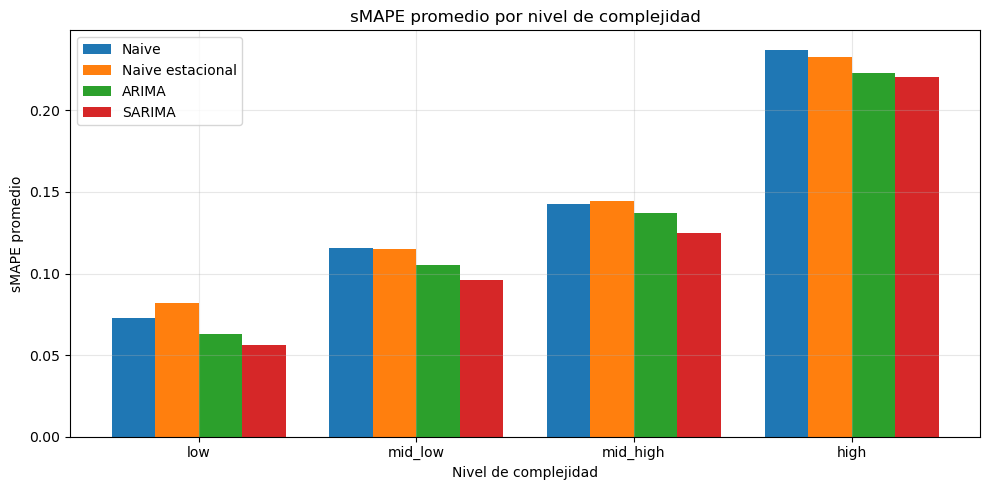

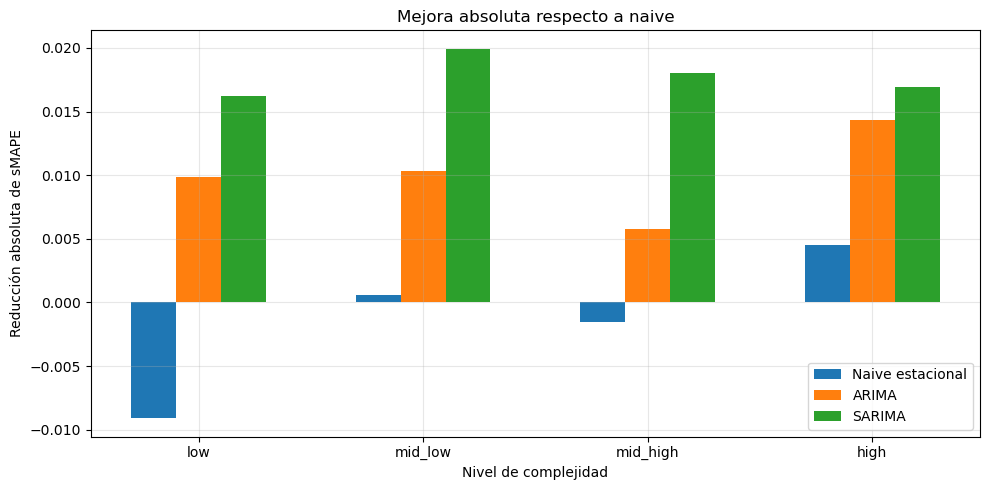

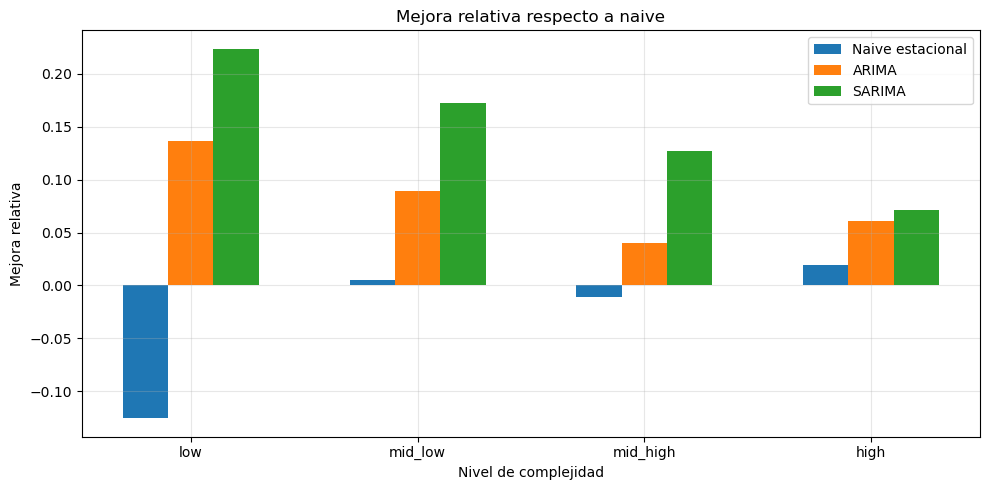


Archivos guardados:
- tabla_resultados_4modelos_complejidad.xlsx
- df_features_4modelos_complejidad.xlsx


In [29]:
# =========================================================
# IMPORTACIONES
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# COPIA DE TRABAJO
# =========================================================

df_eval = df_features.copy()


# =========================================================
# VERIFICACIÓN DE COLUMNAS NECESARIAS
# =========================================================

columnas_necesarias = [
    "complexity_level",
    "error_naive_smape",
    "error_snaive_smape",
    "error_arima_smape",
    "error_sarima_smape"
]

faltantes = [c for c in columnas_necesarias if c not in df_eval.columns]
if faltantes:
    raise ValueError(f"Faltan columnas en df_features: {faltantes}")


# =========================================================
# LIMPIEZA BÁSICA
# =========================================================

df_eval = df_eval.replace([np.inf, -np.inf], np.nan)

# No exigimos que SARIMA exista en todas, porque habrá categorías donde no aplica.
df_eval = df_eval.dropna(subset=["complexity_level", "error_naive_smape", "error_arima_smape"])

print("Series válidas para análisis:", len(df_eval))


# =========================================================
# ORDEN DE NIVELES
# =========================================================

orden_niveles = ["low", "mid_low", "mid_high", "high"]

df_eval["complexity_level"] = pd.Categorical(
    df_eval["complexity_level"],
    categories=orden_niveles,
    ordered=True
)


# =========================================================
# TABLA RESUMEN
# =========================================================

tabla_resumen = df_eval.groupby("complexity_level", observed=True).agg(
    n_series=("complexity_level", "count"),
    naive_smape_mean=("error_naive_smape", "mean"),
    snaive_smape_mean=("error_snaive_smape", "mean"),
    arima_smape_mean=("error_arima_smape", "mean"),
    sarima_smape_mean=("error_sarima_smape", "mean")
).reset_index()

print("\nTabla resumen por nivel de complejidad:")
print(tabla_resumen)


# =========================================================
# MEJORAS ABSOLUTAS
# =========================================================

tabla_resumen["abs_improv_snaive"] = (
    tabla_resumen["naive_smape_mean"] - tabla_resumen["snaive_smape_mean"]
)

tabla_resumen["abs_improv_arima"] = (
    tabla_resumen["naive_smape_mean"] - tabla_resumen["arima_smape_mean"]
)

tabla_resumen["abs_improv_sarima"] = (
    tabla_resumen["naive_smape_mean"] - tabla_resumen["sarima_smape_mean"]
)


# =========================================================
# MEJORAS RELATIVAS CORRECTAS
# =========================================================

tabla_resumen["rel_improv_snaive"] = (
    tabla_resumen["naive_smape_mean"] - tabla_resumen["snaive_smape_mean"]
) / tabla_resumen["naive_smape_mean"]

tabla_resumen["rel_improv_arima"] = (
    tabla_resumen["naive_smape_mean"] - tabla_resumen["arima_smape_mean"]
) / tabla_resumen["naive_smape_mean"]

tabla_resumen["rel_improv_sarima"] = (
    tabla_resumen["naive_smape_mean"] - tabla_resumen["sarima_smape_mean"]
) / tabla_resumen["naive_smape_mean"]

print("\nTabla resumen con mejoras:")
print(tabla_resumen)


# =========================================================
# GRÁFICA 1: sMAPE DE LOS 4 MODELOS
# =========================================================

x = np.arange(len(tabla_resumen))
width = 0.20

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, tabla_resumen["naive_smape_mean"], width, label="Naive")
plt.bar(x - 0.5*width, tabla_resumen["snaive_smape_mean"], width, label="Naive estacional")
plt.bar(x + 0.5*width, tabla_resumen["arima_smape_mean"], width, label="ARIMA")
plt.bar(x + 1.5*width, tabla_resumen["sarima_smape_mean"], width, label="SARIMA")

plt.xticks(x, tabla_resumen["complexity_level"])
plt.title("sMAPE promedio por nivel de complejidad")
plt.xlabel("Nivel de complejidad")
plt.ylabel("sMAPE promedio")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# GRÁFICA 2: MEJORA ABSOLUTA VS NAIVE
# =========================================================

plt.figure(figsize=(10, 5))
plt.bar(x - width, tabla_resumen["abs_improv_snaive"], width, label="Naive estacional")
plt.bar(x,         tabla_resumen["abs_improv_arima"], width, label="ARIMA")
plt.bar(x + width, tabla_resumen["abs_improv_sarima"], width, label="SARIMA")

plt.xticks(x, tabla_resumen["complexity_level"])
plt.title("Mejora absoluta respecto a naive")
plt.xlabel("Nivel de complejidad")
plt.ylabel("Reducción absoluta de sMAPE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# GRÁFICA 3: MEJORA RELATIVA VS NAIVE
# =========================================================

plt.figure(figsize=(10, 5))
plt.bar(x - width, tabla_resumen["rel_improv_snaive"], width, label="Naive estacional")
plt.bar(x,         tabla_resumen["rel_improv_arima"], width, label="ARIMA")
plt.bar(x + width, tabla_resumen["rel_improv_sarima"], width, label="SARIMA")

plt.xticks(x, tabla_resumen["complexity_level"])
plt.title("Mejora relativa respecto a naive")
plt.xlabel("Nivel de complejidad")
plt.ylabel("Mejora relativa")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================
# GUARDAR RESULTADOS
# =========================================================

tabla_resumen.to_excel("tabla_resultados_4modelos_complejidad.xlsx", index=False)
df_eval.to_excel("df_features_4modelos_complejidad.xlsx", index=False)

print("\nArchivos guardados:")
print("- tabla_resultados_4modelos_complejidad.xlsx")
print("- df_features_4modelos_complejidad.xlsx")

In [27]:
# =========================================================
# IMPORTACIONES
# =========================================================

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA


# =========================================================
# CONFIG
# =========================================================

FEATURES_CLUSTER_V2 = [
    "z_skew", "z_kurtosis", "z_entropy", "z_spectral_entropy",
    "z_outlier_ratio", "z_turning_points_ratio", "z_hurst",
    "z_acf1", "z_acf6", "z_acf_freq", "z_acf_decay",
    "z_trend_linearity_r2", "z_curvature_gain", "z_trend_slope",
    "trend_strength", "seasonal_strength",
    "dominant_frequency", "dominant_energy_ratio",
    "adf_pvalue", "kpss_pvalue", "stationarity_conflict",
    "diff_var_ratio", "change_points_per_length",
    "diff_skew", "diff_kurtosis", "diff_entropy",
    "diff_turning_points_ratio", "robust_entropy", "robust_outlier_ratio",
]


# =========================================================
# CARGA DATA
# =========================================================

df = pd.read_excel("features_m4_all_v2.xlsx").copy()


# =========================================================
# FUNCIÓN PARA HACER PCA POR GRUPO
# =========================================================

def compute_complexity_per_group(df_group):

    # ---------------------------
    # Selección de features
    # ---------------------------
    features = [c for c in FEATURES_CLUSTER_V2 if c in df_group.columns]
    X_df = df_group[features].copy()

    X_df = X_df.replace([np.inf, -np.inf], np.nan)
    X_df = X_df.dropna(axis=1, how="all")

    # ---------------------------
    # Variance threshold
    # ---------------------------
    selector = VarianceThreshold(0.0)
    selector.fit(X_df.fillna(X_df.median(numeric_only=True)))
    X_df = X_df[X_df.columns[selector.get_support()]]

    # ---------------------------
    # Imputación
    # ---------------------------
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(X_df)

    # ---------------------------
    # Escalado
    # ---------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imp)

    # ---------------------------
    # PCA
    # ---------------------------
    pca = PCA(n_components=0.90, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # ---------------------------
    # Complexity index
    # ---------------------------
    complexity = -X_pca[:, 0]

    return complexity


# =========================================================
# APLICAR POR FRECUENCIA
# =========================================================

df["complexity_index_freq"] = np.nan

for freq in df["category"].unique():

    print(f"Procesando: {freq}")

    idx = df["category"] == freq
    df_group = df.loc[idx].copy()

    complexity = compute_complexity_per_group(df_group)

    df.loc[idx, "complexity_index_freq"] = complexity


# =========================================================
# NORMALIZAR (IMPORTANTE)
# =========================================================

# Para hacer comparables entre frecuencias
df["complexity_index_freq"] = (
    df.groupby("category")["complexity_index_freq"]
    .transform(lambda x: (x - x.mean()) / x.std())
)


# =========================================================
# CREAR NIVELES POR FRECUENCIA
# =========================================================

df["complexity_level_freq"] = (
    df.groupby("category")["complexity_index_freq"]
    .transform(lambda x: pd.qcut(x, 4, labels=["low","mid_low","mid_high","high"]))
)


# =========================================================
# VERIFICACIÓN
# =========================================================

print(df.groupby(["category","complexity_level_freq"]).size())

Procesando: Yearly
Procesando: Quarterly
Procesando: Monthly
Procesando: Weekly
Procesando: Daily
Procesando: Hourly
category   complexity_level_freq
Daily      low                       1057
           mid_low                   1057
           mid_high                  1056
           high                      1057
Hourly     low                        104
           mid_low                    103
           mid_high                   103
           high                       104
Monthly    low                      12000
           mid_low                  12000
           mid_high                 12000
           high                     12000
Quarterly  low                       6000
           mid_low                   6000
           mid_high                  6000
           high                      6000
Weekly     low                         74
           mid_low                     73
           mid_high                    73
           high                        74
Yearly    

In [34]:
print("df columns:", [c for c in df.columns if "complexity" in c])
print("df_features columns:", [c for c in df_features.columns if "complexity" in c or "error_" in c])

df columns: ['complexity_index_freq', 'complexity_level_freq']
df_features columns: ['complexity_index', 'complexity_level', 'error_naive_smape', 'error_snaive_smape', 'error_arima_smape', 'error_sarima_smape', 'complexity_index_freq', 'complexity_level_freq']


In [32]:
df_features["complexity_index_freq"] = df["complexity_index_freq"].values
df_features["complexity_level_freq"] = df["complexity_level_freq"].values

In [33]:
df_features.groupby(["category", "complexity_level_freq"])[
    ["error_naive_smape", "error_arima_smape"]
].mean()

error_naive_smape  error_arima_smape
category  complexity_level_freq                                      
Daily     low                             0.028866           0.030707
          mid_low                         0.025207           0.025304
          mid_high                        0.031484           0.031192
          high                            0.036254           0.036200
Hourly    low                             0.165756           0.327328
          mid_low                         0.183878           0.302653
          mid_high                        0.502162           0.571804
          high                            0.866650           0.885111
Monthly   low                             0.069994           0.063348
          mid_low                         0.125446           0.121368
          mid_high                        0.151709           0.143629
          high                            0.263110           0.234124
Quarterly low                             0.058383           0.047704
          mid_low                         0.087443           0.079428
          mid_high                        0.124164           0.117509
          high                            0.194421           0.183284
Weekly    low                             0.023301           0.023553
          mid_low                         0.031564           0.032713
          mid_high                        0.067339           0.064182
          high                            0.204831           0.187673
Yearly    low                             0.111589           0.081149
          mid_low                         0.153653           0.130015
          mid_high                        0.167149           0.166045
          high                            0.221296           0.232396

In [35]:
# unir complejidad por frecuencia al dataframe maestro
cols_to_merge = ["serie", "category", "complexity_index_freq", "complexity_level_freq"]

df_features = df_features.drop(
    columns=["complexity_index_freq", "complexity_level_freq"],
    errors="ignore"
)

df_features = df_features.merge(
    df[cols_to_merge],
    on=["serie", "category"],
    how="left"
)

# resumen por frecuencia y nivel de complejidad
resumen_freq = df_features.groupby(["category", "complexity_level_freq"])[
    ["error_naive_smape", "error_arima_smape"]
].mean()

print(resumen_freq)

                                 error_naive_smape  error_arima_smape
category  complexity_level_freq                                      
Daily     low                             0.028866           0.030707
          mid_low                         0.025207           0.025304
          mid_high                        0.031484           0.031192
          high                            0.036254           0.036200
Hourly    low                             0.165756           0.327328
          mid_low                         0.183878           0.302653
          mid_high                        0.502162           0.571804
          high                            0.866650           0.885111
Monthly   low                             0.069994           0.063348
          mid_low                         0.125446           0.121368
          mid_high                        0.151709           0.143629
          high                            0.263110           0.234124
Quarterly low       

In [36]:
# varianza del error por frecuencia
df_features.groupby("category")["error_naive_smape"].std()

category
Daily        0.062812
Hourly       0.418685
Monthly      0.171985
Quarterly    0.139729
Weekly       0.109655
Yearly       0.165201
Name: error_naive_smape, dtype: float64

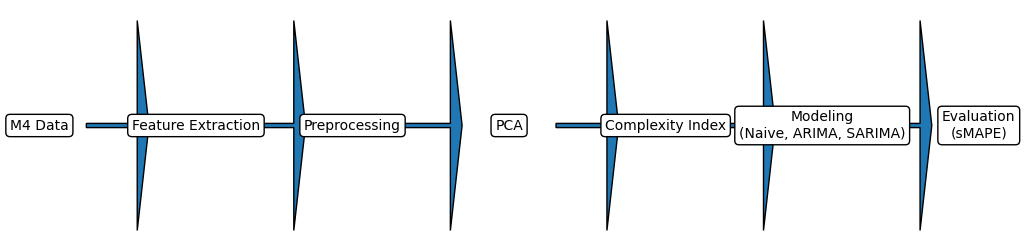

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,3))

steps = [
    "M4 Data",
    "Feature Extraction",
    "Preprocessing",
    "PCA",
    "Complexity Index",
    "Modeling\n(Naive, ARIMA, SARIMA)",
    "Evaluation\n(sMAPE)"
]

for i, step in enumerate(steps):
    ax.text(i, 0, step, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle="round", fc="white"))

for i in range(len(steps)-1):
    ax.arrow(i+0.3, 0, 0.4, 0, head_width=0.05, length_includes_head=True)

ax.axis('off')
plt.savefig("pipeline.png", bbox_inches='tight')
plt.show()